# Paper-Facing Plots

In [1]:

from pathlib import Path
import re
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "new_outputs"
DATA_FALLBACK_DIR = PROJECT_ROOT / "data"
PAPER_DIR = DATA_DIR / "paper_facing_plots"
FIGURE_DIR = PAPER_DIR / "figures"
TABLE_DIR = PAPER_DIR / "tables"
FONT_DIR = FIGURE_DIR / "fonts"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FONT_DIR.mkdir(parents=True, exist_ok=True)

RUNS = {
    "delay_frontier": "delay-frontier-BY2025-fiveyear-cons2025-run0-v2",
    "delay_frontier_robustness": "delay-frontier-BY2025-fiveyear-cons2025-robustness-v2",
    "tree_robustness": "tree-robustness-BY2025-cons2025-samegrid-run0-v1",
    "preference_grid": "preference-grid-BY2025-cons2025-samegrid-run0-v1",
    "technology_grid": "technology-grid-BY2025-cons2025-samegrid-run0-v1",
    "partial_mitigation": "partial-mitigation-BY2025-cons2025-samegrid-run0-cap-v1",
    "damage_robustness": "damage-robustness-BY2025-cons2025-samegrid-run0-v1",
}
BASE_CUMULATIVE_EMISSIONS_GTCO2 = 2730.0


def cm_to_inches(cm):
    return cm / 2.54


JOURNAL_ONE_COLUMN_WIDTH = cm_to_inches(8.7)
JOURNAL_TWO_COLUMN_WIDTH = cm_to_inches(17.8)
JOURNAL_ONE_PANEL_FIGSIZE = (JOURNAL_ONE_COLUMN_WIDTH, cm_to_inches(6.0))
JOURNAL_PRICE_PATHS_FIGSIZE = (JOURNAL_ONE_COLUMN_WIDTH, cm_to_inches(6.2))
JOURNAL_TWO_COLUMN_FIGSIZE = (JOURNAL_TWO_COLUMN_WIDTH, cm_to_inches(12))
JOURNAL_TWO_COLUMN_SQUARE_FIGSIZE = (JOURNAL_TWO_COLUMN_WIDTH, JOURNAL_TWO_COLUMN_WIDTH)
JOURNAL_TWO_COLUMN_TALL_FIGSIZE = (JOURNAL_TWO_COLUMN_WIDTH, cm_to_inches(15.0))
JOURNAL_TREE_APPENDIX_FIGSIZE = (JOURNAL_TWO_COLUMN_WIDTH, cm_to_inches(14.7))
JOURNAL_PARAMS_fonts = {
    "xlabel": 7,
    "ylabel": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.title_fontsize": 6,
    "title.fontsize": 7,
    "panel.labelsize": 8,
    "annotation.fontsize": 6,
}

SI_ROBUSTNESS_FIGSIZE = (10.0, 11.0)
SI_APPENDIX_TREE_FIGSIZE = (8.5, 11.0)
MATLAB_FIGSIZE = JOURNAL_TWO_COLUMN_FIGSIZE
MATLAB_COLORS = [
    "#0000FF", "#EA33F7", "#EA3323", "#000000",
    "#A2FC57", "#76AAF3", "#9C1BC6",
]

sns.set_theme(style="ticks", context="paper")
sns.set_palette(MATLAB_COLORS)
plt.rcParams.update({
    "figure.dpi": 300,
    "figure.figsize": MATLAB_FIGSIZE,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.prop_cycle": plt.cycler(color=MATLAB_COLORS),
    "axes.edgecolor": "black",
    "axes.linewidth": 0.4,
    "axes.grid": False,
    "axes.titlesize": JOURNAL_PARAMS_fonts["title.fontsize"],
    "axes.titleweight": "bold",
    "axes.labelsize": JOURNAL_PARAMS_fonts["xlabel"],
    "axes.labelweight": "normal",
    "xtick.labelsize": JOURNAL_PARAMS_fonts["xtick.labelsize"],
    "ytick.labelsize": JOURNAL_PARAMS_fonts["ytick.labelsize"],
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": True,
    "legend.fancybox": False,
    "legend.edgecolor": "black",
    "legend.facecolor": "white",
    "legend.fontsize": JOURNAL_PARAMS_fonts["legend.fontsize"],
    "legend.title_fontsize": JOURNAL_PARAMS_fonts["legend.title_fontsize"],
    "lines.linewidth": 0.8,
    "lines.markersize": 5,
    "font.family": "Helvetica",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

FRONTIER_LABELS = {
    "low_eis": "Low EIS (0.55)",
    "high_eis": "High EIS (1.86)",
    "low_ra": "Low RA (3)",
    "high_ra": "High RA (15)",
    "no_endogenous_learning": "No endogenous learning",
}
FRONTIER_PLOT_ORDER = ["low_eis", "high_ra", "no_endogenous_learning"]


def run_folder(folder):
    for root in [DATA_DIR, DATA_FALLBACK_DIR]:
        candidate = root / folder
        if candidate.exists():
            return candidate
    return DATA_DIR / folder


def analysis_file(folder, filename):
    return run_folder(folder) / "analysis" / filename


def run_file(folder, kind):
    stem = folder
    return analysis_file(folder, f"{stem}_consolidated_{kind}.csv")


def read_run(folder, kind):
    return pd.read_csv(run_file(folder, kind))


def require_period_len(df, label, expected=5.0):
    if "period_len" not in df:
        decision_cols = [col for col in df.columns if col.startswith("decision_times")]
        if not decision_cols:
            raise ValueError(f"{label} has no period_len or decision_times columns; refusing to use it in paper-facing plots.")
        decision_values = df[decision_cols].stack().dropna().astype(str)
        if decision_values.str.contains(r"(?:^|\|)1(?:\||$)", regex=True).any():
            raise ValueError(f"{label} includes annual decision grids; paper-facing plots require period_len={expected}.")
        return df
    periods = sorted(pd.to_numeric(df["period_len"], errors="coerce").dropna().unique())
    if not periods or any(not np.isclose(period, expected) for period in periods):
        raise ValueError(f"{label} has period_len={periods}; paper-facing plots require period_len={expected}.")
    return df


def select_rows(df, label, **filters):
    mask = pd.Series(True, index=df.index)
    for col, value in filters.items():
        if col not in df:
            raise ValueError(f"{label} is missing required column {col!r}")
        if isinstance(value, (int, float)):
            mask &= np.isclose(pd.to_numeric(df[col], errors="coerce"), value)
        else:
            mask &= df[col].astype(str).eq(str(value))
    out = df.loc[mask].copy()
    if out.empty:
        raise ValueError(f"No rows matched {label}: {filters}")
    return out


def include_figure_fonts(font_families=("Helvetica",)):
    copied = []
    for family in font_families:
        try:
            font_path = Path(font_manager.findfont(family, fallback_to_default=False))
        except Exception:
            font_path = Path(font_manager.findfont(family))
        target = FONT_DIR / font_path.name
        if font_path.exists() and not target.exists():
            shutil.copyfile(font_path, target)
        copied.append(target)
    return copied


FIGURE_FONT_FILES = include_figure_fonts()


def export_figure(fig, filename, dpi=600):
    stem = Path(filename).with_suffix("").name
    paths = {}
    for suffix in (".pdf", ".eps"):
        path = FIGURE_DIR / f"{stem}{suffix}"
        fig.savefig(path, format=suffix.lstrip("."), dpi=dpi, facecolor="white")
        paths[suffix.lstrip(".")] = path
    return paths


def finish_figure(fig, filename, figsize=MATLAB_FIGSIZE, tight=True, dpi=600):
    fig.set_size_inches(*figsize, forward=True)
    if tight:
        fig.tight_layout()
    paths = export_figure(fig, filename, dpi=dpi)
    plt.show()
    return paths["pdf"]


def save_table(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    return path


def add_loss_columns(df):
    out = df.copy()
    pct_col = "delta_c_5yr_pct" if "delta_c_5yr_pct" in out else "delta_c_pct"
    bill_col = "delta_c_5yr_billions" if "delta_c_5yr_billions" in out else "delta_c_billions"
    total_bill_col = "delta_c_5yr_total_billions" if "delta_c_5yr_total_billions" in out else bill_col
    if pct_col in out:
        out["dwl_pct_loss"] = out[pct_col].clip(lower=0)
        out["dwl_metric_source"] = pct_col
    if bill_col in out:
        out["dwl_billions_loss"] = out[bill_col].clip(lower=0)
        out["dwl_trillions_loss"] = out["dwl_billions_loss"] / 1000.0
        out["dwl_billions_metric_source"] = bill_col
    if total_bill_col in out:
        out["dwl_total_billions_loss"] = out[total_bill_col].clip(lower=0)
        out["dwl_total_trillions_loss"] = out["dwl_total_billions_loss"] / 1000.0
    if "extra_cumulative_emissions" in out:
        out["extra_cumulative_emissions_gtco2"] = out["extra_cumulative_emissions"] * 1000.0
    return out


def summarize_results(df, group_cols):
    out = add_loss_columns(df)
    metric_cols = [
        "delta_c_5yr", "dwl_pct_loss", "dwl_billions_loss", "deadweight_per_ton",
        "carbon_price_optimal", "carbon_price_delayed", "m_optimal_period0",
        "m_delayed_period0", "mitigation_foregone", "utility_loss", "welfare_loss",
        "extra_cumulative_emissions", "reentry_price_increase",
        "reentry_price_pct_increase", "reentry_price_annualized_increase",
        "peak_catchup_mitigation", "ppm_at_reentry", "temperature_at_reentry",
    ]
    metric_cols = [col for col in metric_cols if col in out.columns]
    summary = out.groupby(group_cols, dropna=False)[metric_cols].agg(["mean", "std", "count"])
    summary.columns = [f"{metric}_{stat}" for metric, stat in summary.columns]
    return summary.reset_index()


def build_partial_welfare(df):
    out = add_loss_columns(df).copy()
    out["dwl_phi"] = pd.to_numeric(out["delta_c_5yr"], errors="coerce")
    out["dwl_pct"] = pd.to_numeric(out["delta_c_5yr_pct"], errors="coerce")
    out["dwl_billions"] = pd.to_numeric(out["delta_c_5yr_billions"], errors="coerce")
    out["dwl_phi_loss"] = out["dwl_phi"].clip(lower=0)
    out["utility_loss_raw"] = pd.to_numeric(out["utility_loss"], errors="coerce")
    out["utility_loss_loss"] = out["utility_loss_raw"].clip(lower=0)
    baseline = out.loc[out["partial_mitigation_pct"] == 0, [
        "delay_year", "dwl_pct_loss", "utility_loss_loss",
    ]].rename(columns={
        "dwl_pct_loss": "baseline_dwl_pct_loss",
        "utility_loss_loss": "baseline_utility_loss_loss",
    })
    out = out.merge(baseline, on="delay_year", how="left", validate="many_to_one")
    out["share_of_dwl_avoided"] = (
        1.0 - out["dwl_pct_loss"] / out["baseline_dwl_pct_loss"]
    ).where(out["baseline_dwl_pct_loss"] > 0, 0.0).clip(lower=0, upper=1)
    out["share_of_loss_avoided"] = (
        1.0 - out["utility_loss_loss"] / out["baseline_utility_loss_loss"]
    ).where(out["baseline_utility_loss_loss"] > 0, 0.0).clip(lower=0, upper=1)
    return out


def style_axes(ax):
    ax.grid(False)
    ax.tick_params(top=True, right=True, direction="in")
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)


def add_panel_label(ax, label, x=-0.13, y=1.08, fontsize=None):
    if fontsize is None:
        fontsize = JOURNAL_PARAMS_fonts["panel.labelsize"]
    ax.text(x, y, label, transform=ax.transAxes, ha="left", va="bottom", fontsize=fontsize, fontweight="bold", clip_on=False)


def plot_group_lines(ax, data, x, y, order, styles, label_col="frontier_label"):
    handles, labels = [], []
    for key in order:
        sub = data.loc[data["frontier_spec"] == key].sort_values(x)
        if sub.empty:
            continue
        color, marker, linestyle, linewidth = styles[key]
        line = ax.plot(
            sub[x], sub[y], linestyle=linestyle, marker=marker,
            color=color, markerfacecolor="none", linewidth=linewidth,
            label=sub[label_col].iloc[0],
        )[0]
        handles.append(line)
        labels.append(sub[label_col].iloc[0])
    style_axes(ax)
    return handles, labels


def melt_timeseries(df, prefixes, id_cols):
    cols = [c for c in df.columns if any(c.startswith(prefix + "_") for prefix in prefixes)]
    long = df[id_cols + cols].melt(id_vars=id_cols, value_vars=cols, var_name="variable", value_name="value")
    long["year"] = long["variable"].str.extract(r"_(\d{4})$").astype(int)
    long["series"] = long["variable"].str.replace(r"_\d{4}$", "", regex=True)
    long["value"] = pd.to_numeric(long["value"], errors="coerce")
    return long.dropna(subset=["value"])


In [2]:
delay_frontier_results = require_period_len(read_run(RUNS["delay_frontier"], "results"), RUNS["delay_frontier"])
delay_frontier_robustness_results = require_period_len(
    read_run(RUNS["delay_frontier_robustness"], "results"), RUNS["delay_frontier_robustness"]
)
tree_results = require_period_len(read_run(RUNS["tree_robustness"], "results"), RUNS["tree_robustness"])
preference_results = require_period_len(read_run(RUNS["preference_grid"], "results"), RUNS["preference_grid"])
technology_results = require_period_len(read_run(RUNS["technology_grid"], "results"), RUNS["technology_grid"])
partial_results = add_loss_columns(
    require_period_len(read_run(RUNS["partial_mitigation"], "results"), RUNS["partial_mitigation"])
)
damage_results = require_period_len(read_run(RUNS["damage_robustness"], "results"), RUNS["damage_robustness"])

frontier_node_prices = pd.read_csv(
    analysis_file(RUNS["delay_frontier"], f"{RUNS['delay_frontier']}_node_prices.csv")
)
frontier_node_prices = require_period_len(frontier_node_prices, f"{RUNS['delay_frontier']} node prices")

tree_robustness_node_prices = pd.read_csv(
    analysis_file(RUNS["tree_robustness"], f"{RUNS['tree_robustness']}_node_prices.csv")
)

partial_welfare = build_partial_welfare(partial_results)
tree_robustness_summary = summarize_results(tree_results, ["delay_year", "tree_spec"])
preference_grid_summary = summarize_results(preference_results, ["delay_year", "ra", "eis", "pref"])
technology_grid_summary = summarize_results(technology_results, ["delay_year", "tech_chg", "tech_scale"])
damage_robustness_summary = summarize_results(
    damage_results, ["delay_year", "dam_func", "tip_on", "d_unc", "t_unc"]
)
save_table(partial_welfare, "partial_mitigation_welfare_avoided.csv")
save_table(tree_robustness_summary, "tree_robustness_summary.csv")
save_table(preference_grid_summary, "preference_grid_summary.csv")
save_table(technology_grid_summary, "technology_grid_summary.csv")
save_table(damage_robustness_summary, "damage_robustness_summary.csv")

def frontier_variant(df, frontier_spec, frontier_label, **filters):
    out = add_loss_columns(select_rows(df, frontier_label, **filters))
    out = out.sort_values("delay_year").copy()
    out["frontier_spec"] = frontier_spec
    out["frontier_label"] = frontier_label
    return out


frontier_base = frontier_variant(
    delay_frontier_results, "baseline", "Baseline 5-year frontier",
    sample_index="run0_params", tree_spec="default", ra=10.0, eis=0.833, pref=0.002, tech_chg=1.5, tech_scale=1.5,
    dam_func=0, tip_on=1,
)
frontier_robust_plot = pd.concat([
    frontier_variant(
        delay_frontier_robustness_results, "low_eis", FRONTIER_LABELS["low_eis"],
        sample_index="low_eis", tree_spec="default", ra=10.0, eis=0.55, pref=0.002, tech_chg=1.5, tech_scale=1.5,
        dam_func=0, tip_on=1,
    ),
    frontier_variant(
        delay_frontier_robustness_results, "high_ra", FRONTIER_LABELS["high_ra"],
        sample_index="high_ra", tree_spec="default", ra=15.0, eis=0.833, pref=0.002, tech_chg=1.5, tech_scale=1.5,
        dam_func=0, tip_on=1,
    ),
    frontier_variant(
        delay_frontier_robustness_results, "no_endogenous_learning", FRONTIER_LABELS["no_endogenous_learning"],
        sample_index="no_endogenous_learning", tree_spec="default", ra=10.0, eis=0.833, pref=0.002, tech_chg=1.5, tech_scale=0.0,
        dam_func=0, tip_on=1,
    ),
], ignore_index=True, sort=False)
frontier_plot = pd.concat([frontier_base, frontier_robust_plot], ignore_index=True, sort=False)
save_table(frontier_plot, "fiveyear_delay_frontier_plot_data.csv")
save_table(frontier_plot, "annual_delay_frontier_plot_data.csv")

frontier_styles = {
    "baseline": (MATLAB_COLORS[0], "o", "-", 1.2),
    "low_eis": (MATLAB_COLORS[3], "s", "--", 1.0),
    "high_ra": (MATLAB_COLORS[2], "v", "--", 1.0),
    "no_endogenous_learning": (MATLAB_COLORS[6], "x", "--", 1.0),
}
frontier_order = ["baseline", *FRONTIER_PLOT_ORDER]
frontier_specs = [
    ("dwl_pct_loss", "Consumption-Equivalent DWL", "DWL (%)"),
    ("extra_cumulative_emissions_gtco2", "Extra Cumulative Emissions", "GtCO2"),
    ("reentry_price_increase", "Re-Entry Price Increase", "$/tCO2"),
]
ratio = frontier_plot.loc[
    (frontier_plot["dwl_pct_loss"] > 0) & frontier_plot["dwl_trillions_loss"].notna(),
    "dwl_trillions_loss",
] / frontier_plot.loc[
    (frontier_plot["dwl_pct_loss"] > 0) & frontier_plot["dwl_trillions_loss"].notna(),
    "dwl_pct_loss",
]
DWL_TRILLIONS_PER_PERCENT = float(ratio.median())

marginal_plot = frontier_plot.sort_values(["frontier_spec", "delay_year"]).copy()
for col, mv_col in [
    ("dwl_pct_loss", "mv_dwl_pct"),
    ("dwl_trillions_loss", "mv_dwl_trillions"),
    ("utility_loss_pct", "mv_utility_loss_pct"),
    ("extra_cumulative_emissions_gtco2", "mv_extra_emissions_gtco2"),
    ("reentry_price_increase", "mv_reentry_price_increase"),
]:
    marginal_plot[mv_col] = marginal_plot.groupby("frontier_spec")[col].diff()
for mv_col in ["mv_dwl_pct", "mv_dwl_trillions", "mv_utility_loss_pct", "mv_extra_emissions_gtco2", "mv_reentry_price_increase"]:
    marginal_plot[mv_col] = marginal_plot[mv_col].fillna(0.0)
marginal_base = marginal_plot.loc[marginal_plot["frontier_spec"] == "baseline"].copy()
save_table(marginal_plot[[
    "frontier_spec", "frontier_label", "delay_year", "mv_dwl_pct", "mv_dwl_trillions",
    "mv_utility_loss_pct", "mv_extra_emissions_gtco2", "mv_reentry_price_increase",
]], "marginal_value_five_year_plot_data.csv")
save_table(marginal_plot[[
    "frontier_spec", "frontier_label", "delay_year", "mv_dwl_pct", "mv_dwl_trillions",
    "mv_utility_loss_pct", "mv_extra_emissions_gtco2", "mv_reentry_price_increase",
]], "marginal_value_one_year_plot_data.csv")

PosixPath('/Users/theomoers/Documents/Research/CKI/EZDelay/data/new_outputs/paper_facing_plots/tables/marginal_value_one_year_plot_data.csv')

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


1 extra bytes in post.stringData array


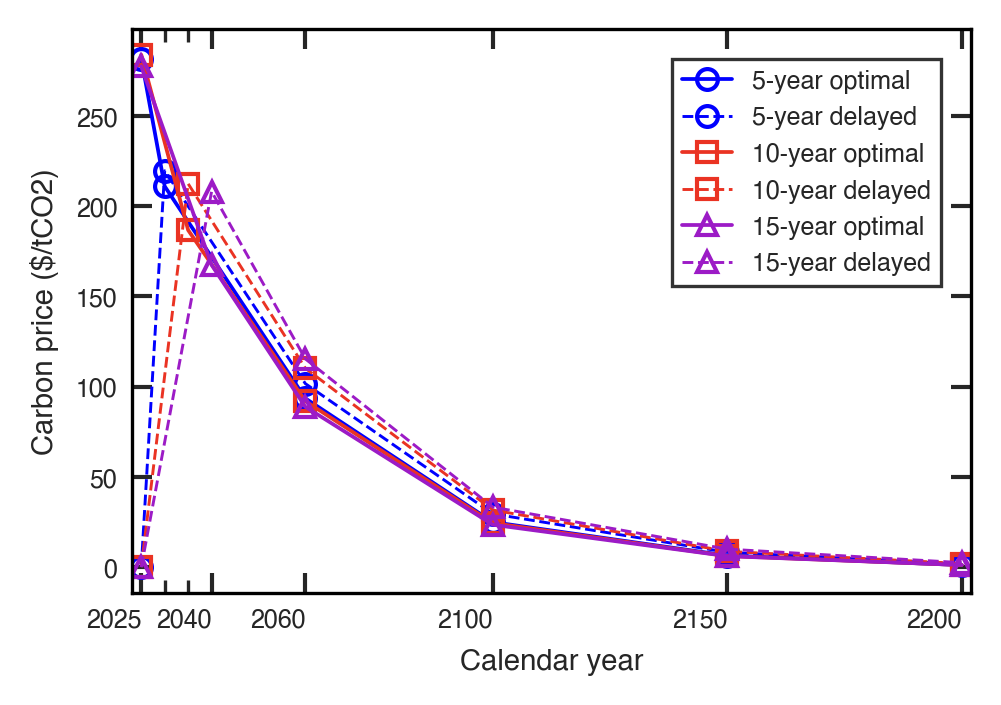

PosixPath('/Users/theomoers/Documents/Research/CKI/EZDelay/data/new_outputs/paper_facing_plots/figures/policy_reentry_paths_first_panel.pdf')

In [3]:
selected_delays = [5, 10, 15]
delay_path_styles = {
    5: (MATLAB_COLORS[0], "o"),
    10: (MATLAB_COLORS[2], "s"),
    15: (MATLAB_COLORS[6], "^"),
}
scenario_styles = {
    "optimal": ("-", 0.9, "optimal"),
    "delayed": ("--", 0.7, "delayed"),
}
path_order = [(delay, scenario) for delay in selected_delays for scenario in ["optimal", "delayed"]]


def expected_node_path(node_df, delay_year, scenario, label):
    sub = node_df.loc[
        (node_df["delay_year"] == delay_year) & (node_df["scenario"] == scenario)
    ].copy()
    if sub.empty:
        return pd.DataFrame(columns=["path_label", "delay_year", "scenario", "calendar_year", "price"])
    rows = []
    for year, year_df in sub.groupby("calendar_year"):
        weights = pd.to_numeric(year_df["node_probability"], errors="coerce").fillna(0.0)
        weight_sum = weights.sum()
        if weight_sum <= 0:
            continue
        rows.append({
            "path_label": label,
            "delay_year": delay_year,
            "scenario": scenario,
            "calendar_year": int(year),
            "price": np.average(pd.to_numeric(year_df["price"], errors="coerce"), weights=weights),
        })
    return pd.DataFrame(rows)


path_parts = []
for delay, scenario in path_order:
    path_parts.append(expected_node_path(frontier_node_prices, delay, scenario, f"{delay}-year {scenario}"))
policy_paths = pd.concat(path_parts, ignore_index=True).sort_values(["delay_year", "scenario", "calendar_year"])
policy_decision_years = sorted(policy_paths["calendar_year"].dropna().astype(int).unique())
save_table(policy_paths, "policy_reentry_expected_paths.csv")

fig, ax = plt.subplots(figsize=JOURNAL_PRICE_PATHS_FIGSIZE)
for delay, scenario in path_order:
    sub = policy_paths.loc[
        (policy_paths["delay_year"] == delay) & (policy_paths["scenario"] == scenario)
    ].sort_values("calendar_year")
    if sub.empty:
        continue
    color, marker = delay_path_styles[delay]
    linestyle, linewidth, scenario_label = scenario_styles[scenario]
    ax.plot(
        sub["calendar_year"], sub["price"], linestyle=linestyle, marker=marker,
        color=color, markerfacecolor="none", linewidth=linewidth,
        label=f"{delay}-year {scenario_label}",
    )
ax.set_xlabel("Calendar year", fontsize=JOURNAL_PARAMS_fonts["xlabel"])
ax.set_ylabel("Carbon price ($/tCO2)", fontsize=JOURNAL_PARAMS_fonts["ylabel"])
ax.set_xlim(min(policy_decision_years) - 2, max(policy_decision_years) + 2)
major_policy_years = [2025, 2040, 2060, 2100, 2150, 2200]
minor_policy_years = [year for year in policy_decision_years if year not in major_policy_years]
ax.set_xticks(major_policy_years)
ax.set_xticks(minor_policy_years, minor=True)
ax.set_yticks(np.arange(0, 300, 50))
ax.set_xticklabels([str(year) for year in major_policy_years])
style_axes(ax)
ax.tick_params(axis="x", labelsize=JOURNAL_PARAMS_fonts["xtick.labelsize"])
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
ax.legend(loc="upper right", frameon=True, fontsize=JOURNAL_PARAMS_fonts["legend.fontsize"], ncol=1, borderaxespad=1.2)

finish_figure(fig, "policy_reentry_paths_first_panel.pdf", figsize=JOURNAL_PRICE_PATHS_FIGSIZE)


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


1 extra bytes in post.stringData array


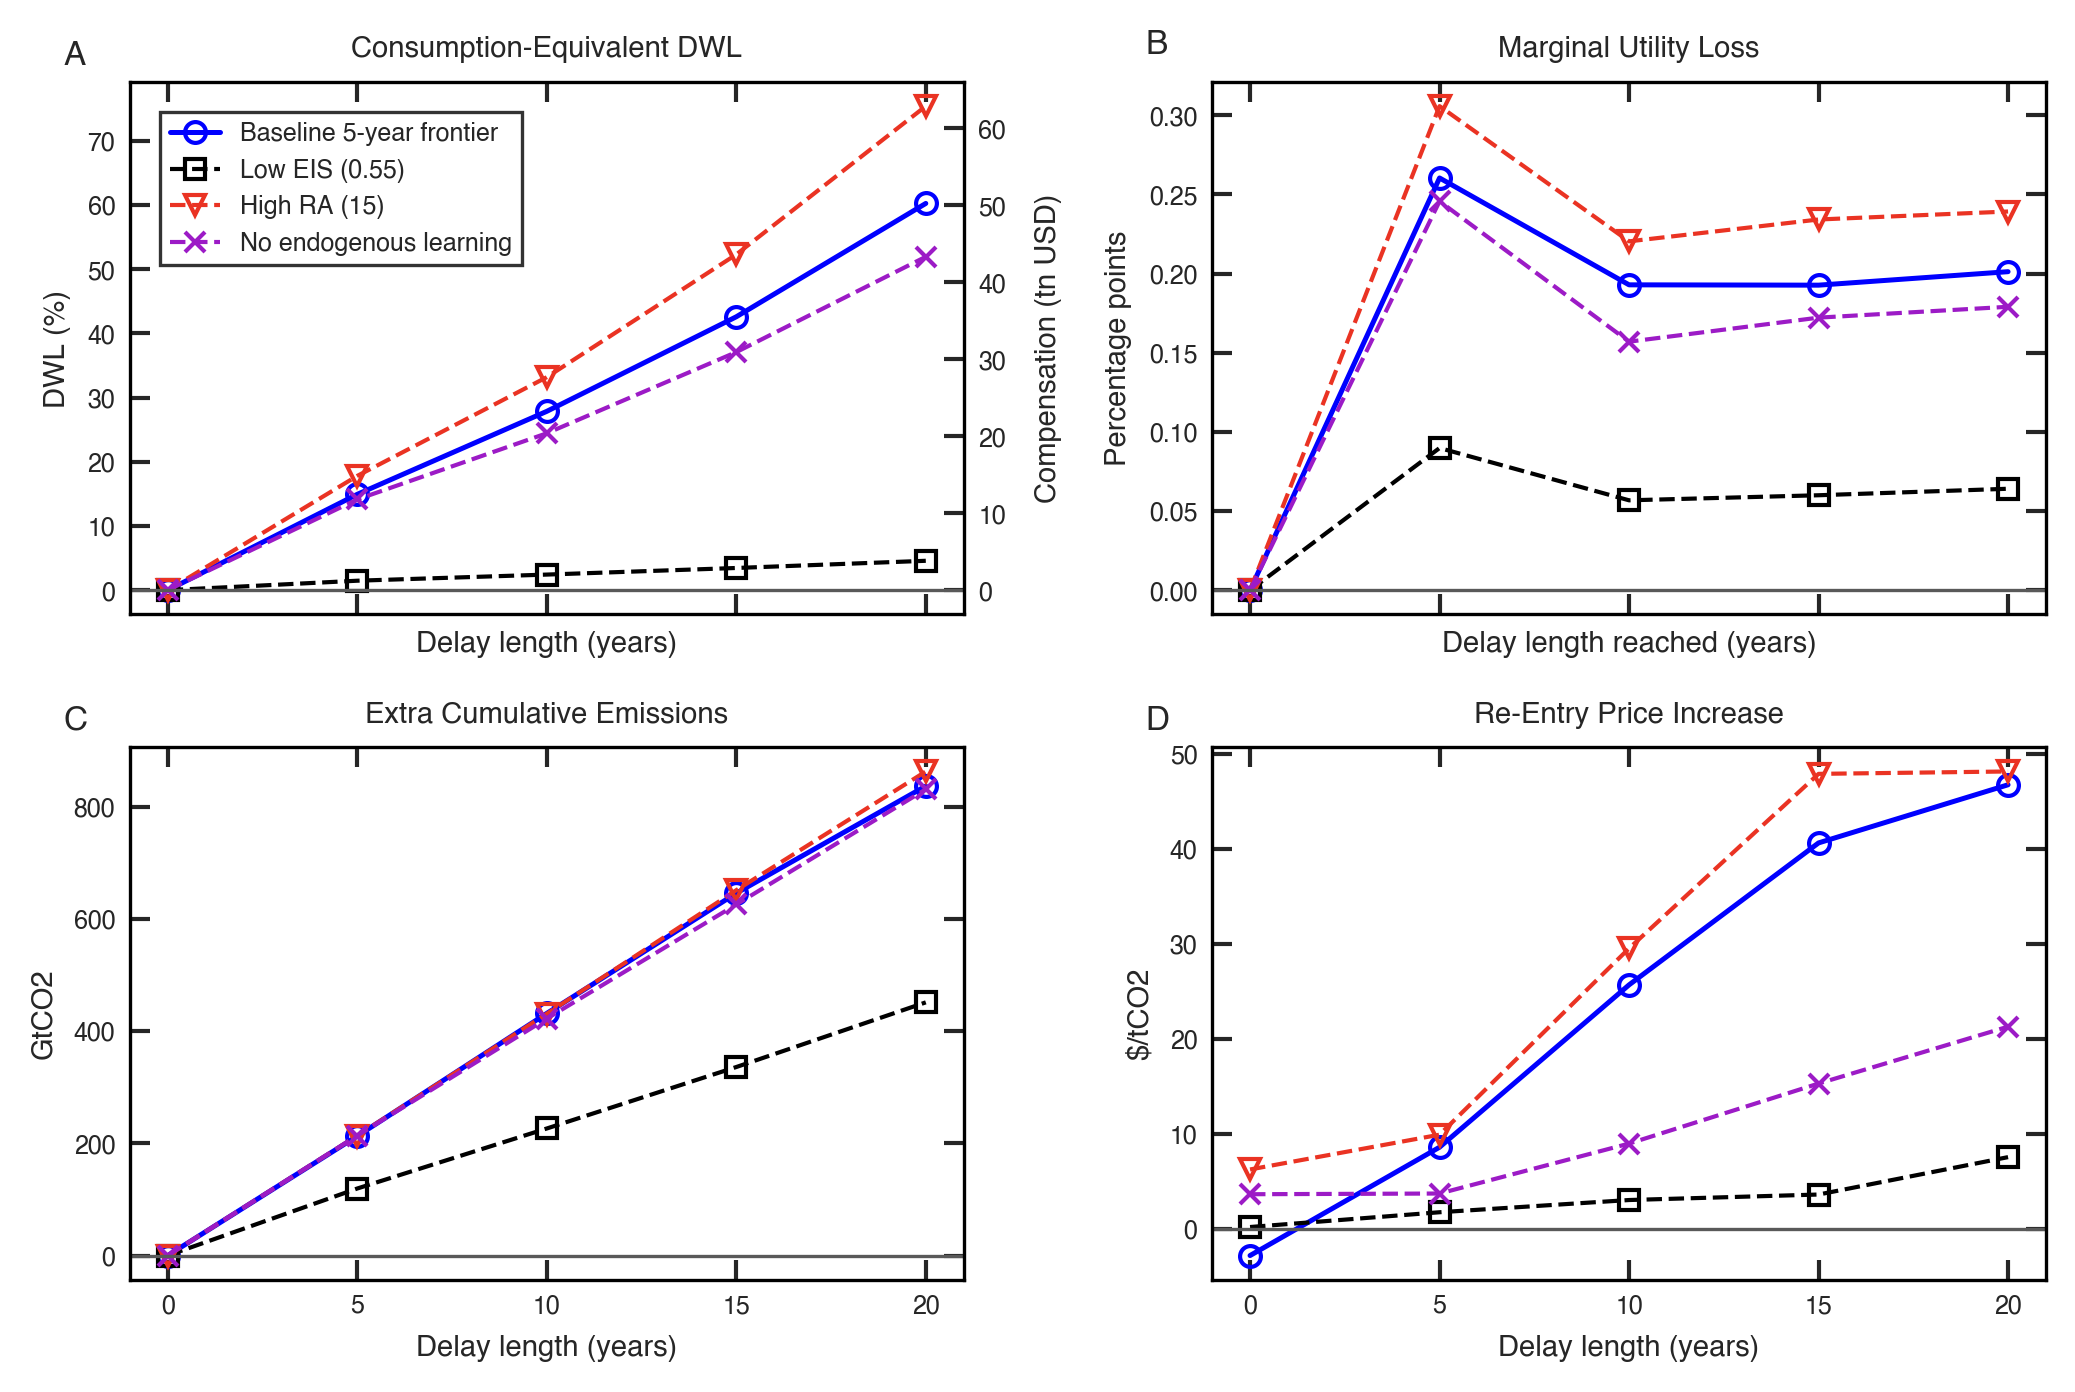

PosixPath('/Users/theomoers/Documents/Research/CKI/EZDelay/data/new_outputs/paper_facing_plots/figures/annual_delay_frontier_four_panel.pdf')

In [4]:
fig, axes = plt.subplots(2, 2, figsize=MATLAB_FIGSIZE, sharex=True)
legend_handles, legend_labels = [], []

panel_map = {
    0: frontier_specs[0],
    2: frontier_specs[1],
    3: frontier_specs[2],
}
for panel_index, (col, title, ylabel) in panel_map.items():
    ax = axes.flat[panel_index]
    add_panel_label(ax, chr(ord("A") + panel_index), y=1.02, x=-0.08)
    handles, labels = plot_group_lines(ax, frontier_plot, "delay_year", col, frontier_order, frontier_styles)
    if not legend_handles:
        legend_handles, legend_labels = handles, labels
    ax.axhline(0, color="0.35", linewidth=0.8)
    ax.set_title(title, fontsize=JOURNAL_PARAMS_fonts["title.fontsize"])
    ax.set_xlabel("Delay length (years)", fontsize=JOURNAL_PARAMS_fonts["xlabel"])
    ax.set_ylabel(ylabel, fontsize=JOURNAL_PARAMS_fonts["ylabel"])
    if ax is axes.flat[0]:
        ax.legend(loc="upper left", frameon=True, fontsize=JOURNAL_PARAMS_fonts["legend.fontsize"], borderaxespad=1.2)

ax = axes.flat[1]
add_panel_label(ax, "B", y=1.04, x=-0.08)
plot_group_lines(ax, marginal_plot, "delay_year", "mv_utility_loss_pct", frontier_order, frontier_styles)
ax.axhline(0, color="0.35", linewidth=0.8)
ax.set_title("Marginal Utility Loss", fontsize=JOURNAL_PARAMS_fonts["title.fontsize"])
ax.set_xlabel("Delay length reached (years)", fontsize=JOURNAL_PARAMS_fonts["xlabel"])
ax.set_ylabel("Percentage points", fontsize=JOURNAL_PARAMS_fonts["ylabel"])
# Set x labels in lower row to 0, 5, 10, 15, 20
ax.set_xticks([0, 5, 10, 15, 20])

ax.tick_params(right=True)

secax = axes.flat[0].secondary_yaxis(
    "right",
    functions=(
        lambda pct: pct * DWL_TRILLIONS_PER_PERCENT,
        lambda tn: tn / DWL_TRILLIONS_PER_PERCENT,
    ),
)
secax.set_ylabel("Compensation (tn USD)", fontsize=JOURNAL_PARAMS_fonts["ylabel"], labelpad=7)
axes.flat[0].tick_params(right=False)
secax.tick_params(direction="in", labelsize=JOURNAL_PARAMS_fonts["ytick.labelsize"], left=False, right=True)

fig.subplots_adjust(wspace=0.42)
#fig.legend(legend_handles, legend_labels, loc="lower center", ncol=2, frameon=True, bbox_to_anchor=(0.5, -0.08))
finish_figure(fig, "annual_delay_frontier_four_panel.pdf")



1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


1 extra bytes in post.stringData array


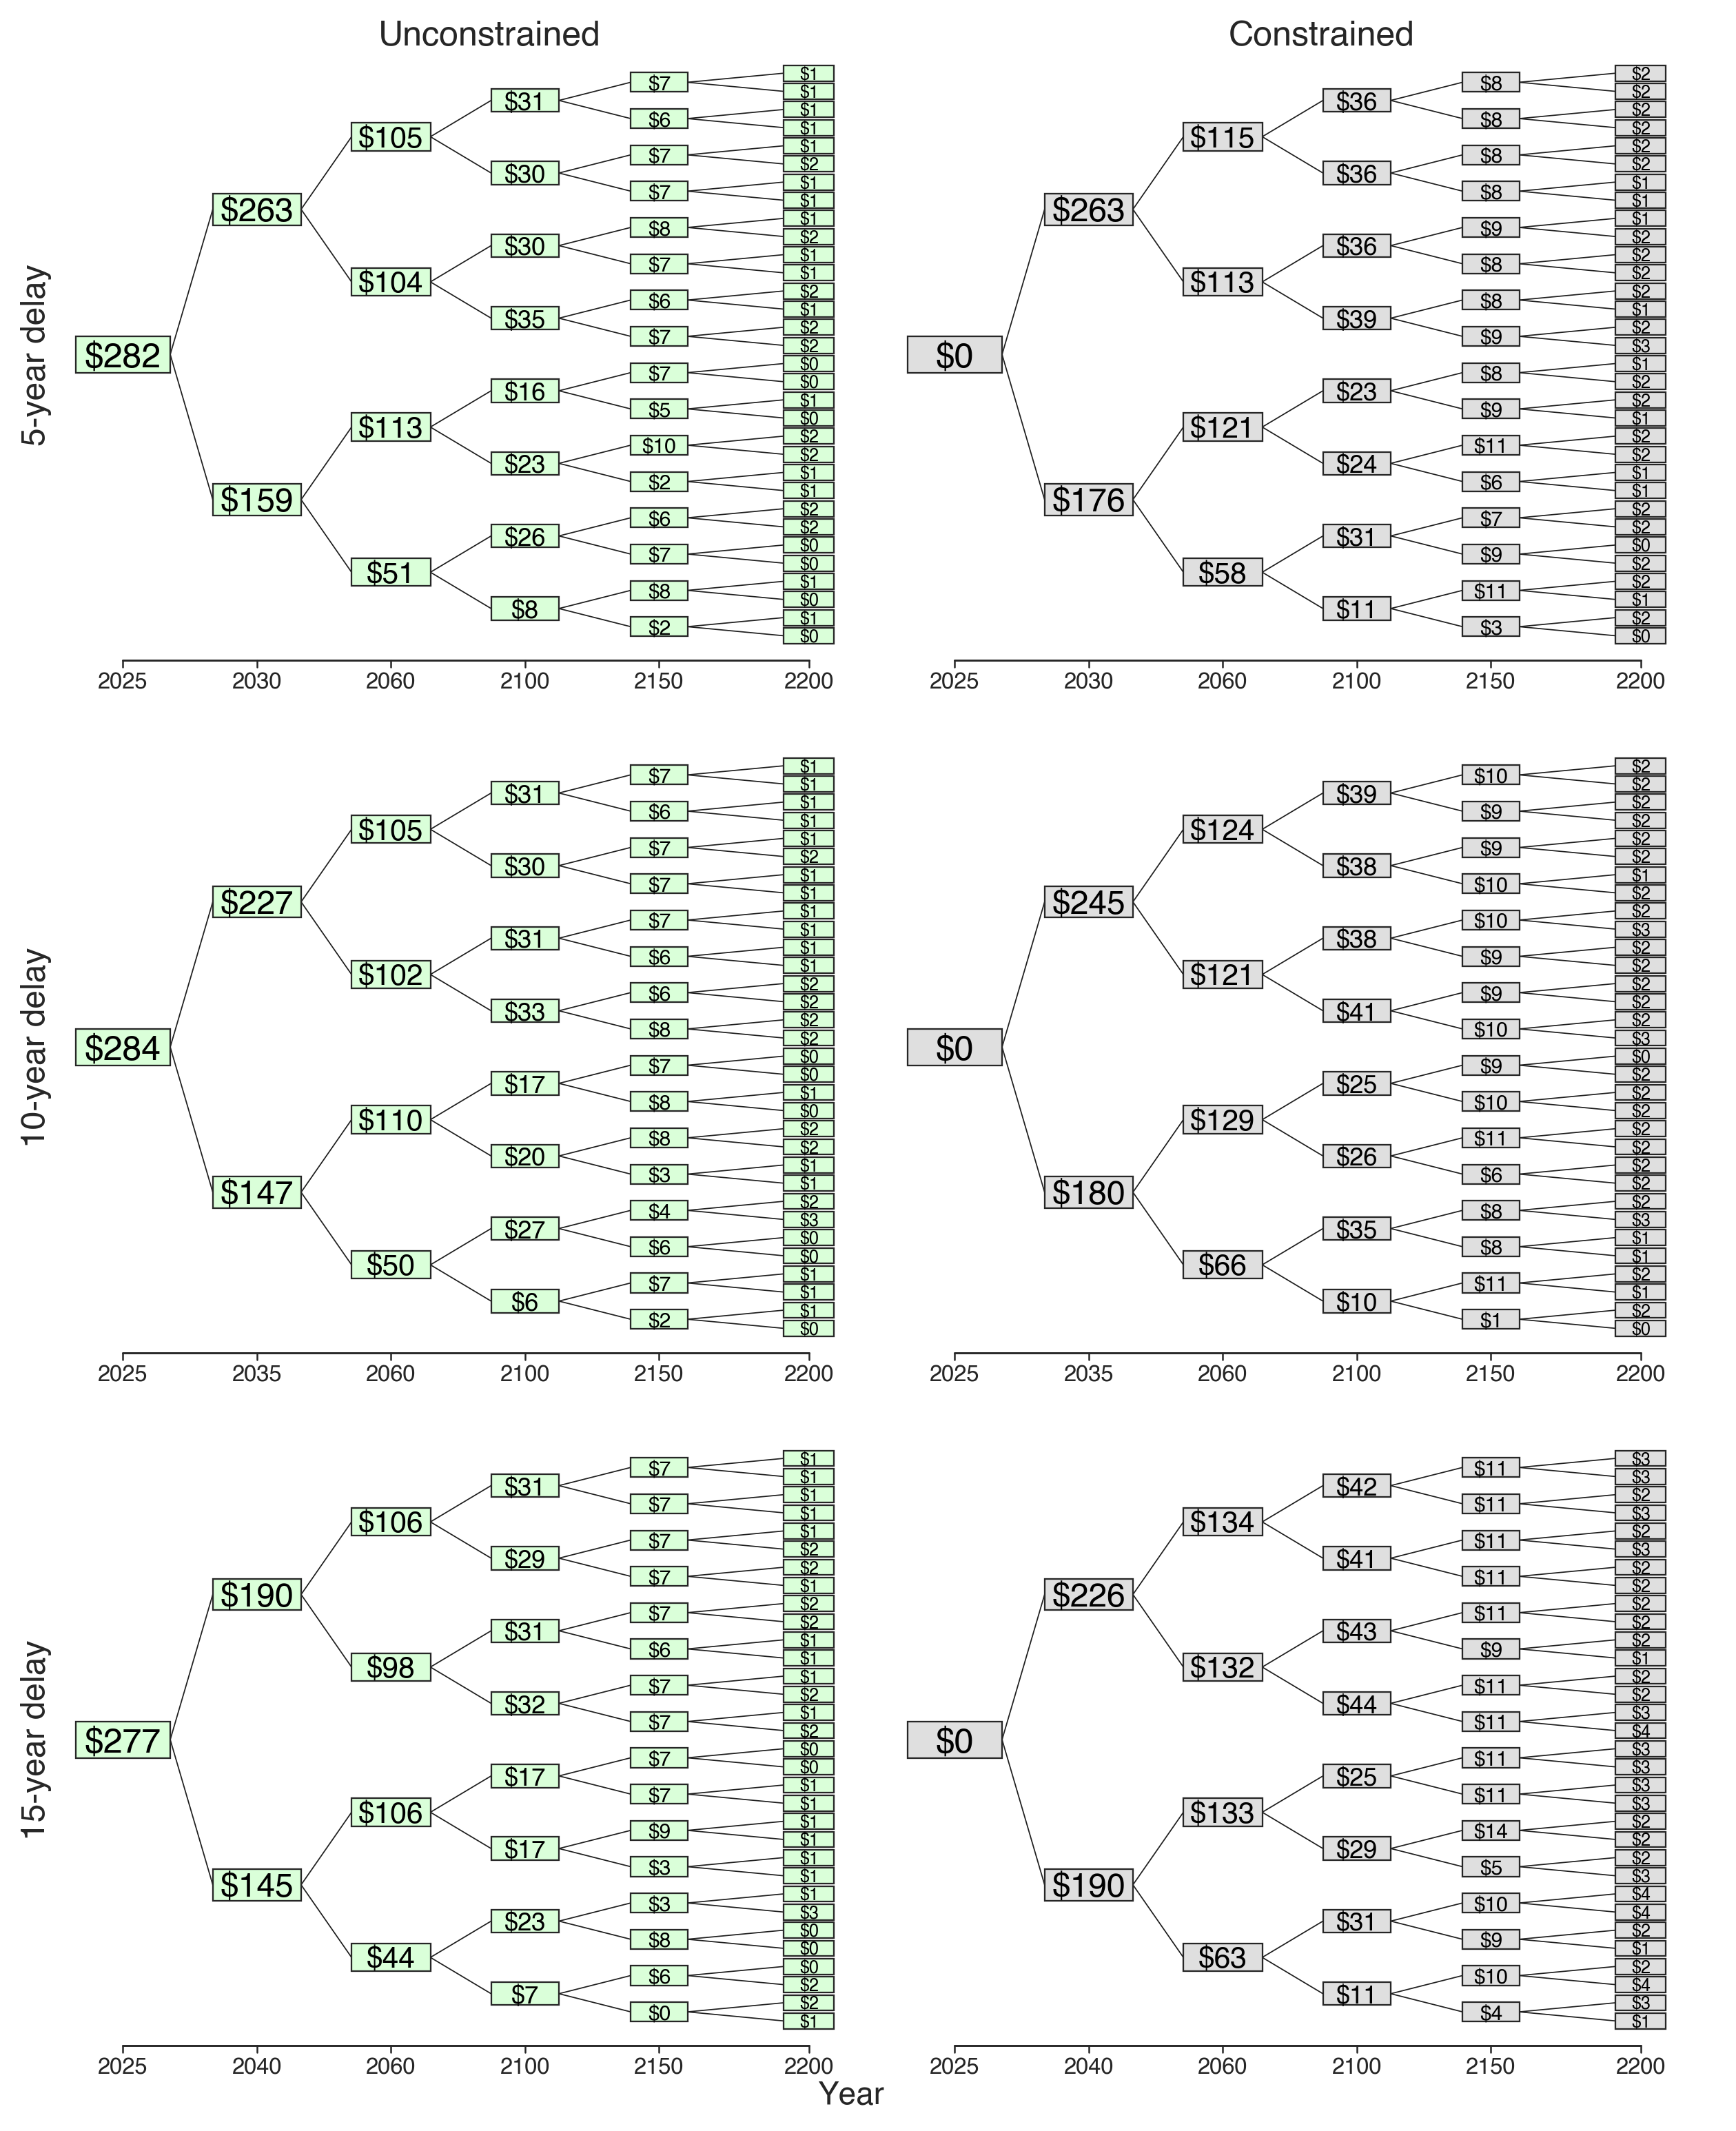

PosixPath('/Users/theomoers/Documents/Research/CKI/EZDelay/data/new_outputs/paper_facing_plots/figures/appendix_carbon_price_trees_optimal_delayed.pdf')

In [5]:
from matplotlib.patches import Rectangle

APPENDIX_TREE_DELAYS = [5, 10, 15]
APPENDIX_TREE_SCENARIOS = [
    ("optimal", "Unconstrained"),
    ("delayed", "Constrained"),
]


def appendix_price_nodes(node_df, delay_year, scenario):
    sub = node_df.loc[
        (node_df["delay_year"] == delay_year) & (node_df["scenario"] == scenario)
    ].copy()
    if sub.empty:
        raise ValueError(f"Missing node prices for delay={delay_year}, scenario={scenario}")
    sub["node"] = pd.to_numeric(sub["node"], errors="coerce").astype(int)
    sub["period"] = pd.to_numeric(sub["period"], errors="coerce").astype(int)
    sub["calendar_year"] = pd.to_numeric(sub["calendar_year"], errors="coerce").astype(int)
    sub["price"] = pd.to_numeric(sub["price"], errors="coerce")
    sub = sub.sort_values("node")
    prices = sub["price"].to_numpy(dtype=float)
    decision_years = [
        int(sub.loc[sub["period"] == period, "calendar_year"].iloc[0])
        for period in sorted(sub["period"].unique())
    ]
    return prices, decision_years


def appendix_tree_coordinates(n_periods=6):
    final_period = n_periods - 1
    final_y = np.linspace(0.965, 0.035, 2 ** final_period)
    x_by_period = np.array([0.035, 0.205, 0.375, 0.545, 0.715, 0.905])
    coords = {}
    for period in range(n_periods):
        descendants_per_node = 2 ** (final_period - period)
        for node_in_period in range(2 ** period):
            start = node_in_period * descendants_per_node
            stop = (node_in_period + 1) * descendants_per_node
            y = final_y[start:stop].mean()
            node = 2 ** period - 1 + node_in_period
            coords[node] = (x_by_period[period], y, period, node_in_period)
    return coords


APPENDIX_TREE_COORDS = appendix_tree_coordinates(n_periods=6)
APPENDIX_BOX_STYLE = {
    0: (0.120, 0.060, 12.0),
    1: (0.112, 0.052, 11.5),
    2: (0.100, 0.046, 10.2),
    3: (0.086, 0.038, 8.7),
    4: (0.072, 0.032, 7.2),
    5: (0.064, 0.026, 6.0),
}
APPENDIX_TREE_FACE = {
    "optimal": "#daffd9",
    "delayed": "#dfdfdf",
}


def appendix_price_label(value):
    if not np.isfinite(value):
        return ""
    return f"${value:,.0f}"


def draw_appendix_price_tree(ax, prices, decision_years, scenario, title=None, row_label=None):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_facecolor("white")
    ax.set_yticks([])
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    n_nodes = len(prices)
    for node in range(1, n_nodes):
        parent = (node - 1) // 2
        if parent not in APPENDIX_TREE_COORDS or node not in APPENDIX_TREE_COORDS:
            continue
        x0, y0, parent_period, _ = APPENDIX_TREE_COORDS[parent]
        x1, y1, child_period, _ = APPENDIX_TREE_COORDS[node]
        parent_w = APPENDIX_BOX_STYLE[parent_period][0]
        child_w = APPENDIX_BOX_STYLE[child_period][0]
        ax.plot(
            [x0 + parent_w / 2, x1 - child_w / 2], [y0, y1],
            color="0.12", lw=0.42, transform=ax.transAxes, clip_on=False, zorder=1,
        )

    for node, price in enumerate(prices):
        if node not in APPENDIX_TREE_COORDS:
            continue
        x, y, period, _ = APPENDIX_TREE_COORDS[node]
        width, height, fontsize = APPENDIX_BOX_STYLE[period]
        rect = Rectangle(
            (x - width / 2, y - height / 2), width, height,
            transform=ax.transAxes, facecolor=APPENDIX_TREE_FACE[scenario],
            edgecolor="0.15", linewidth=0.55, zorder=2, clip_on=False,
        )
        ax.add_patch(rect)
        ax.text(
            x, y, appendix_price_label(price), transform=ax.transAxes,
            ha="center", va="center_baseline", fontsize=fontsize,
            fontfamily="Helvetica", fontweight="bold", color="black", zorder=3,
            clip_on=False,
        )

    tick_y = -0.025
    year_x = [APPENDIX_TREE_COORDS[2 ** period - 1][0] for period in range(len(decision_years))]
    for period, year in enumerate(decision_years):
        x = year_x[period]
        ax.plot([x, x], [-0.006, -0.017], color="0.15", lw=0.6, transform=ax.transAxes, clip_on=False)
        ax.text(
            x, tick_y, str(year), transform=ax.transAxes,
            ha="center", va="top", fontsize=7.8, fontfamily="Helvetica", clip_on=False,
        )
    ax.plot([year_x[0], year_x[-1]], [-0.006, -0.006], color="0.15", lw=0.7, transform=ax.transAxes, clip_on=False)

    if title:
        ax.set_title(title, loc="center", fontsize=12, fontweight="bold", fontfamily="Helvetica", pad=1)
    if row_label:
        ax.text(
            -0.075, 0.5, row_label, transform=ax.transAxes,
            rotation=90, ha="center", va="center", fontsize=11.5,
            fontfamily="Helvetica", fontweight="bold", clip_on=False,
        )


fig, axes = plt.subplots(len(APPENDIX_TREE_DELAYS), 2, figsize=SI_APPENDIX_TREE_FIGSIZE, constrained_layout=False)
appendix_tree_rows = []
for row, delay_year in enumerate(APPENDIX_TREE_DELAYS):
    for col, (scenario, scenario_title) in enumerate(APPENDIX_TREE_SCENARIOS):
        ax = axes[row, col]
        prices, decision_years = appendix_price_nodes(frontier_node_prices, delay_year, scenario)
        row_label = f"{delay_year}-year delay" if col == 0 else None
        title = scenario_title if row == 0 else None
        draw_appendix_price_tree(ax, prices, decision_years, scenario, title=title, row_label=row_label)
        for node, price in enumerate(prices):
            period = int(np.floor(np.log2(node + 1)))
            appendix_tree_rows.append({
                "delay_year": delay_year,
                "scenario": scenario,
                "node": node,
                "period": period,
                "calendar_year": decision_years[period],
                "price": price,
            })

fig.supxlabel("Year", fontsize=11, fontweight="bold", fontfamily="Helvetica", y=0.020)
fig.subplots_adjust(left=0.070, right=0.992, top=0.925, bottom=0.050, hspace=0.145, wspace=0.055)

save_table(pd.DataFrame(appendix_tree_rows), "appendix_carbon_price_trees_plot_data.csv")
appendix_tree_pdf = finish_figure(
    fig,
    "appendix_carbon_price_trees_optimal_delayed.pdf",
    figsize=SI_APPENDIX_TREE_FIGSIZE,
    tight=False,
)
appendix_tree_pdf


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


1 extra bytes in post.stringData array


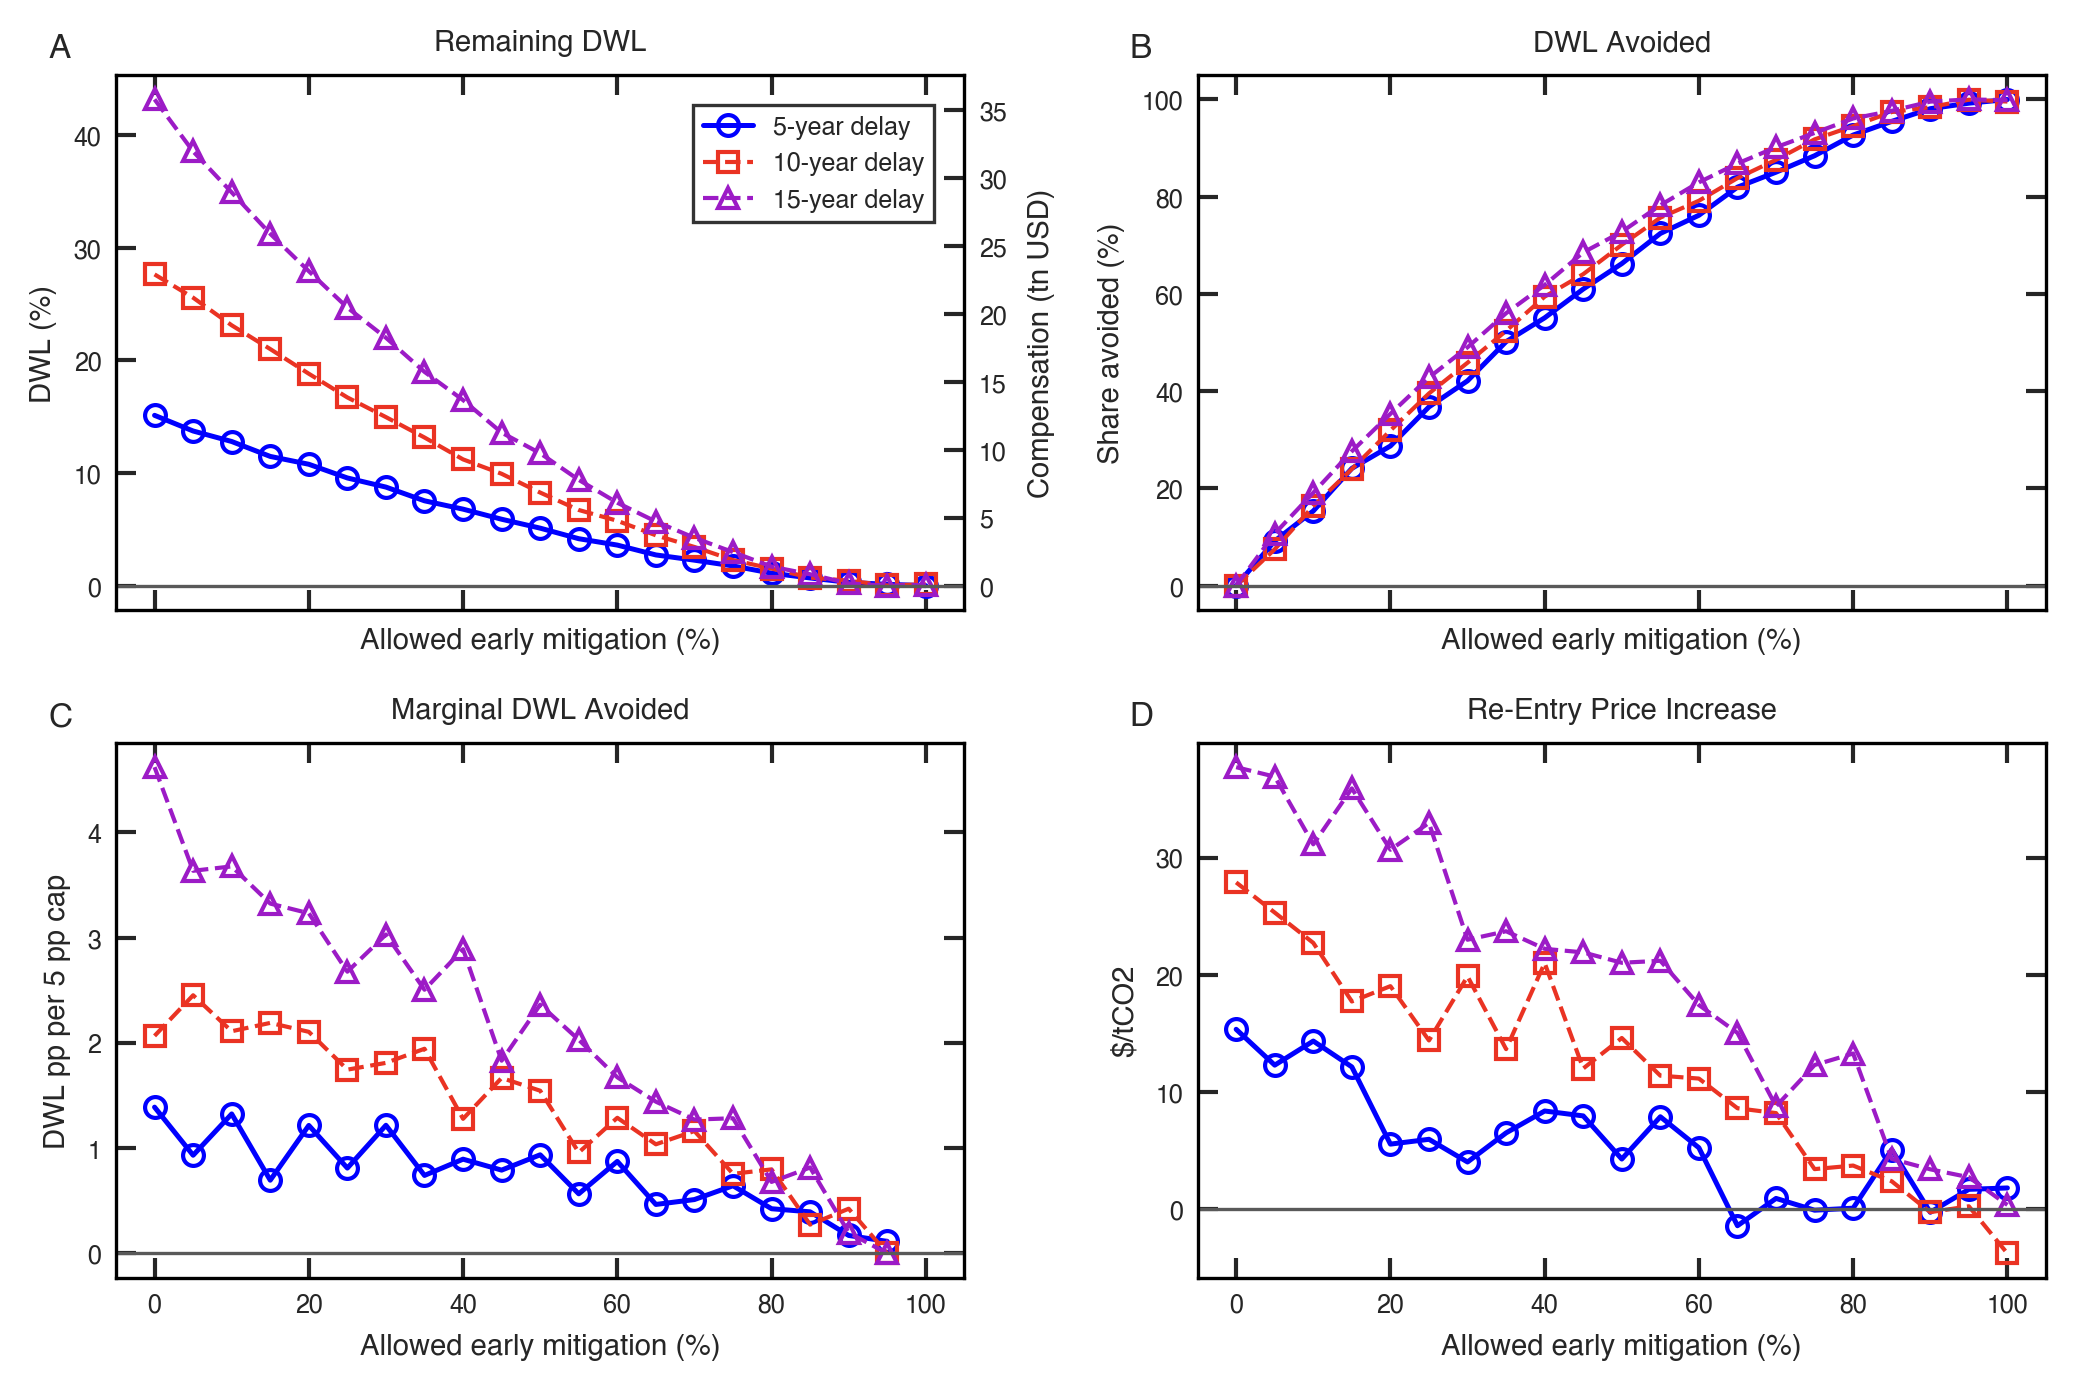

PosixPath('/Users/theomoers/Documents/Research/CKI/EZDelay/data/new_outputs/paper_facing_plots/figures/partial_mitigation_four_panel.pdf')

In [6]:
partial_mechanisms = partial_results.copy()
partial_mechanisms["residual_emissions_delay_window_gtco2"] = (
    1000.0 * partial_mechanisms["cumulative_emissions_at_reentry"] - BASE_CUMULATIVE_EMISSIONS_GTCO2
).clip(lower=0)
partial_mechanisms = partial_mechanisms.groupby(["delay_year", "partial_mitigation_pct"])[
    ["residual_emissions_delay_window_gtco2"]
].mean().reset_index()

partial_plot = partial_welfare.merge(partial_mechanisms, on=["delay_year", "partial_mitigation_pct"], how="left")
partial_plot["dwl_trillions_loss"] = partial_plot["dwl_billions_loss"] / 1000.0
partial_plot["share_of_dwl_avoided_pct"] = (100.0 * partial_plot["share_of_dwl_avoided"]).clip(lower=0, upper=100)
partial_plot["share_of_loss_avoided_pct"] = (100.0 * partial_plot["share_of_loss_avoided"]).clip(lower=0, upper=100)
partial_plot = partial_plot.sort_values(["delay_year", "partial_mitigation_pct"]).copy()
partial_plot["marginal_dwl_avoided_pp"] = partial_plot.groupby("delay_year")["dwl_pct_loss"].diff(-1)
partial_plot["marginal_dwl_avoided_pp"] = partial_plot["marginal_dwl_avoided_pp"].clip(lower=0)
save_table(partial_plot, "partial_mitigation_frontier_plot_data.csv")

partial_styles = {
    5: (MATLAB_COLORS[0], "o", "-", 1.2),
    10: (MATLAB_COLORS[2], "s", "--", 1.0),
    15: (MATLAB_COLORS[6], "^", "--", 1.0),
}
partial_specs = [
    ("dwl_pct_loss", "Remaining DWL", "DWL (%)"),
    ("share_of_dwl_avoided_pct", "DWL Avoided", "Share avoided (%)"),
    ("marginal_dwl_avoided_pp", "Marginal DWL Avoided", "DWL pp per 5 pp cap"),
    ("reentry_price_increase", "Re-Entry Price Increase", "$/tCO2"),
]
fig, axes = plt.subplots(2, 2, figsize=MATLAB_FIGSIZE, sharex=True)
legend_handles, legend_labels = [], []
for panel_i, (ax, (col, title, ylabel)) in enumerate(zip(axes.flat, partial_specs)):
    add_panel_label(ax, chr(ord("A") + panel_i), y=1.02, x=-0.08)
    for delay in [5, 10, 15]:
        sub = partial_plot.loc[partial_plot["delay_year"] == delay].sort_values("partial_mitigation_pct")
        color, marker, linestyle, linewidth = partial_styles[delay]
        line = ax.plot(
            sub["partial_mitigation_pct"], sub[col], linestyle=linestyle, marker=marker,
            color=color, markerfacecolor="none", linewidth=linewidth, label=f"{delay}-year delay",
        )[0]
        if ax is axes.flat[0]:
            legend_handles.append(line)
            legend_labels.append(f"{delay}-year delay")
    ax.axhline(0, color="0.35", linewidth=0.8)
    ax.set_title(title, fontsize=JOURNAL_PARAMS_fonts["title.fontsize"])
    ax.set_xlabel("Allowed early mitigation (%)", fontsize=JOURNAL_PARAMS_fonts["xlabel"])
    ax.set_ylabel(ylabel, fontsize=JOURNAL_PARAMS_fonts["ylabel"])
    style_axes(ax)
    if ax is axes.flat[0]:
        ax.legend(loc="upper right", frameon=True, fontsize=JOURNAL_PARAMS_fonts["legend.fontsize"], borderaxespad=1.2)

panel_a = axes.flat[0]
comp_scale = partial_plot.loc[partial_plot["dwl_pct_loss"] > 0, "dwl_trillions_loss"].div(
    partial_plot.loc[partial_plot["dwl_pct_loss"] > 0, "dwl_pct_loss"]
).median()
secax_a = panel_a.secondary_yaxis("right", functions=(lambda y: y * comp_scale, lambda y: y / comp_scale))
secax_a.set_ylabel("Compensation (tn USD)", fontsize=JOURNAL_PARAMS_fonts["ylabel"], labelpad=5)
panel_a.tick_params(right=False)
secax_a.tick_params(direction="in", right=True, labelsize=JOURNAL_PARAMS_fonts["ytick.labelsize"])
#fig.legend(legend_handles, legend_labels, loc="lower center", ncol=3, frameon=True, bbox_to_anchor=(0.5, -0.06))
finish_figure(fig, "partial_mitigation_four_panel.pdf")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


1 extra bytes in post.stringData array


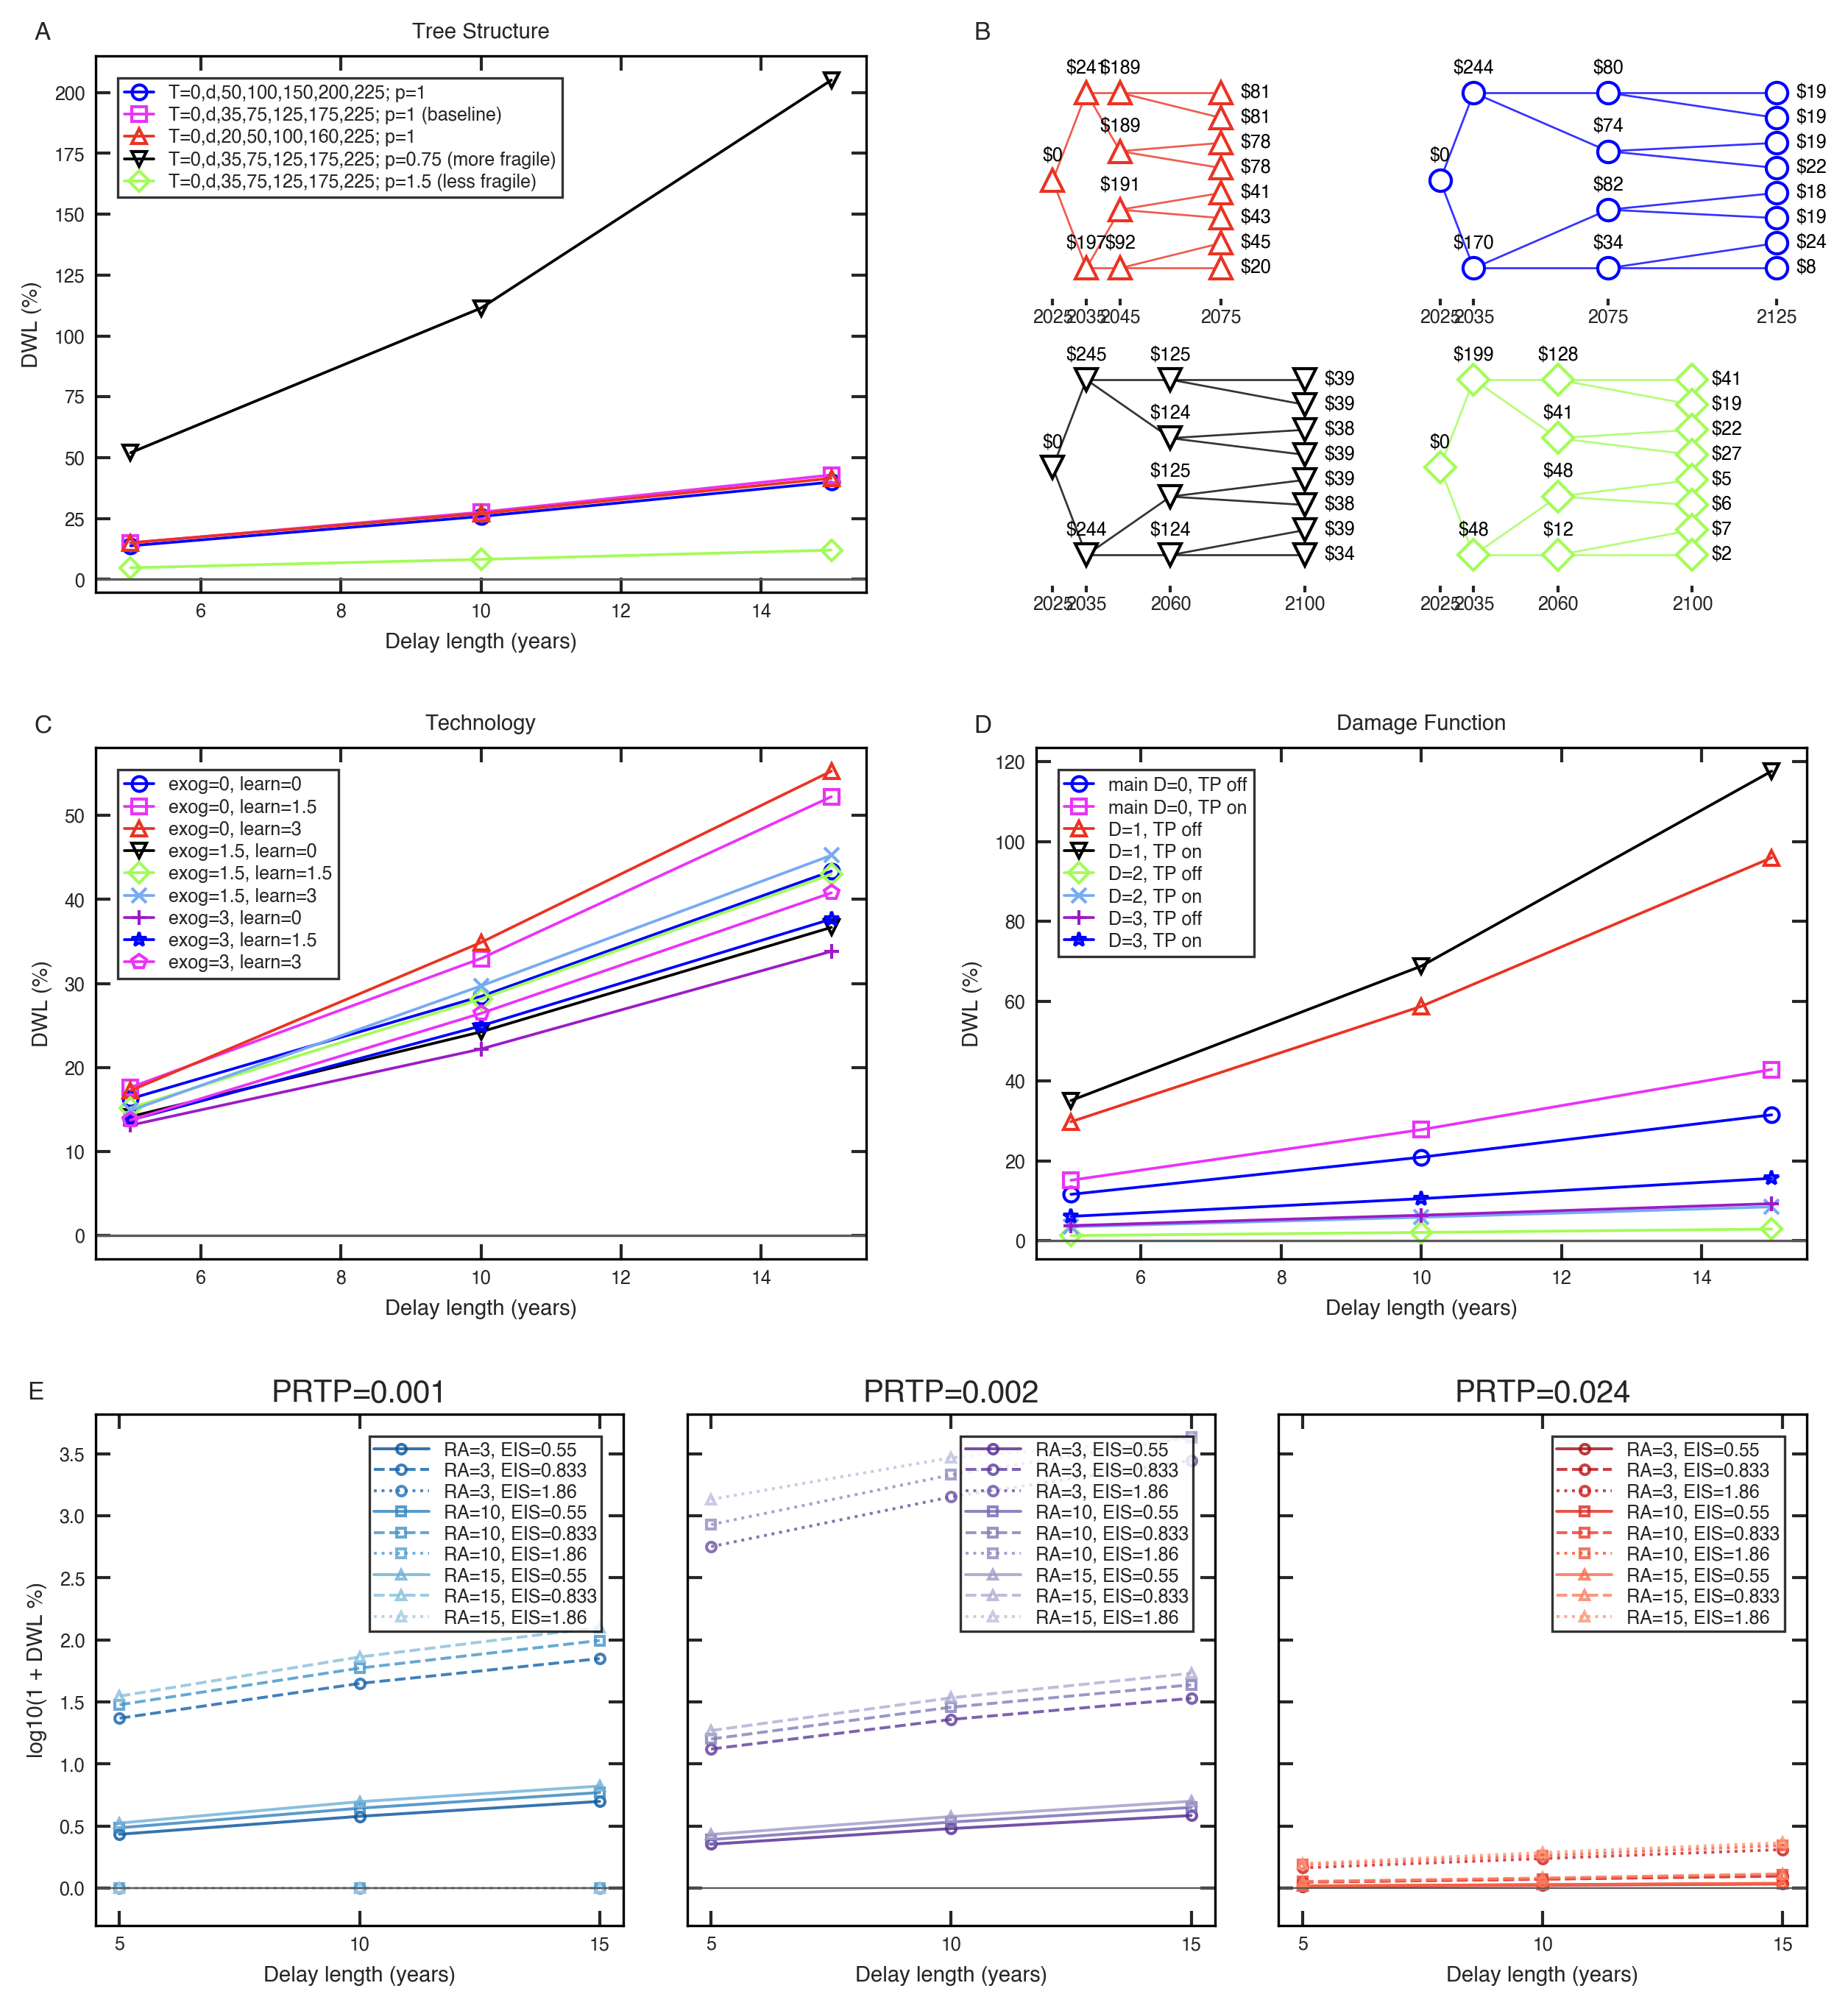

PosixPath('/Users/theomoers/Documents/Research/CKI/EZDelay/data/new_outputs/paper_facing_plots/figures/robustness_ranges_four_panel.pdf')

In [7]:

TREE_ROBUSTNESS_LABELS = {
    "default": "T=0,d,35,75,125,175,225; p=1 (baseline)",
    "standard_10yr_second_decision": "legacy 2nd=10 -> T=0,d,35,75,125,175,225",
    "front_loaded_decisions": "T=0,d,20,50,100,160,225; p=1",
    "back_loaded_decisions": "T=0,d,50,100,150,200,225; p=1",
    "higher_fragility_weight": "T=0,d,35,75,125,175,225; p=0.75 (more fragile)",
    "lower_fragility_weight": "T=0,d,35,75,125,175,225; p=1.5 (less fragile)",
}
TREE_INSET_LABELS = {
    "front_loaded_decisions": "Front-loaded",
    "back_loaded_decisions": "Back-loaded",
    "higher_fragility_weight": "p=0.75",
    "lower_fragility_weight": "p=1.5",
}
ROBUST_MARKERS = ["o", "s", "^", "v", "D", "x", "+", "*", "p", "h"]
ROBUST_LINESTYLES = ["-", "--", "-.", ":"]


def variant_label(row, family):
    if family == "tree":
        return TREE_ROBUSTNESS_LABELS.get(row["tree_spec"], str(row["tree_spec"]))
    if family == "technology":
        return f"exog={row['tech_chg']:g}, learn={row['tech_scale']:g}"
    if family == "damage":
        damage_name = "main D=0" if int(row["dam_func"]) == 0 else f"D={int(row['dam_func'])}"
        tipping = "TP on" if int(row["tip_on"]) == 1 else "TP off"
        return f"{damage_name}, {tipping}"
    if family == "preference":
        return f"RA={row['ra']:g}, EIS={row['eis']:g}, PRTP={row['pref']:g}"
    return "variant"


def plot_variant_panel(ax, frame, family, group_cols, title, ylabel="DWL (%)", transform=None,
                       legend_fontsize=6.0, legend_ncol=1):
    handles, labels = [], []
    frame = frame.copy().sort_values(group_cols + ["delay_year"])
    for idx, (keys, sub) in enumerate(frame.groupby(group_cols, sort=False)):
        sub = sub.sort_values("delay_year").copy()
        y = pd.to_numeric(sub["dwl_pct_loss_mean"], errors="coerce").clip(lower=0)
        if transform is not None:
            y = transform(y)
        color = MATLAB_COLORS[idx % len(MATLAB_COLORS)]
        marker = ROBUST_MARKERS[idx % len(ROBUST_MARKERS)]
        linestyle = ROBUST_LINESTYLES[(idx // len(ROBUST_MARKERS)) % len(ROBUST_LINESTYLES)]
        line = ax.plot(
            sub["delay_year"], y,
            color=color,
            marker=marker,
            linestyle=linestyle,
            markerfacecolor="none",
            linewidth=0.9,
            markersize=4.8,
        )[0]
        handles.append(line)
        labels.append(variant_label(sub.iloc[0], family))
    ax.axhline(0, color="0.35", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Delay length (years)")
    ax.set_ylabel(ylabel)
    style_axes(ax)
    ax.legend(handles, labels, frameon=True, loc="upper left", fontsize=legend_fontsize,
              ncol=legend_ncol, handlelength=1.6, borderpad=0.35, labelspacing=0.25,  borderaxespad=1.2)


def plot_preference_range_panel(ax, frame):
    pref_range = frame.groupby("delay_year")["dwl_pct_loss_mean"].agg(["min", "median", "max"]).reset_index()
    x = pref_range["delay_year"].to_numpy(dtype=float)
    y_min = pref_range["min"].to_numpy(dtype=float)
    y_med = pref_range["median"].to_numpy(dtype=float)
    y_max = pref_range["max"].to_numpy(dtype=float)
    positive_values = pref_range[["min", "median", "max"]].to_numpy(dtype=float)
    positive_values = positive_values[positive_values > 0]
    positive_floor = 0.1
    ax.fill_between(x, np.maximum(y_min, positive_floor), y_max, color=MATLAB_COLORS[0], alpha=0.16, linewidth=0)
    ax.plot(x, y_max, color=MATLAB_COLORS[2], marker="^", markerfacecolor="none", linewidth=1.0, label="max")
    ax.plot(x, y_med, color="black", marker="o", markerfacecolor="none", linewidth=1.1, label="median", linestyle="--")
    ax.plot(x, np.maximum(y_min, positive_floor), color=MATLAB_COLORS[0], marker="s", markerfacecolor="none", linewidth=1.0, label="min")
    ax.set_yscale("log")
    ax.set_ylim(bottom=positive_floor)
    ax.set_title("Preference Range", fontsize=12, fontweight="bold")
    ax.set_xlabel("Delay length (years)")
    ax.set_ylabel("DWL (%)")
    style_axes(ax)
    ax.legend(frameon=True, loc="upper left", fontsize=7, ncol=1, borderaxespad=1.2)


def plot_price_tree(ax, node_df, tree_spec, delay_year=10, max_period=3, color="black", marker="o", xlim=None):
    sub = node_df.loc[
        (node_df["tree_spec"] == tree_spec)
        & (node_df["delay_year"] == delay_year)
        & (node_df["scenario"] == "delayed")
        & (node_df["period"] <= max_period)
    ].copy()
    if sub.empty:
        ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return None
    positions = {}
    for period, per in sub.groupby("period"):
        per = per.sort_values("node")
        n = len(per)
        ys = np.linspace(0.45, -0.45, n) if n > 1 else np.array([0.0])
        for y, (_, row) in zip(ys, per.iterrows()):
            positions[int(row["node"])] = (int(row["calendar_year"]), float(y))
    for period in sorted(sub["period"].unique()):
        if period >= max_period:
            continue
        parents = sub.loc[sub["period"] == period].sort_values("node")
        children = sub.loc[sub["period"] == period + 1].sort_values("node")
        child_nodes = children["node"].astype(int).tolist()
        for k, parent_node in enumerate(parents["node"].astype(int).tolist()):
            for child_node in child_nodes[2 * k: 2 * k + 2]:
                if parent_node in positions and child_node in positions:
                    x0, y0 = positions[parent_node]
                    x1, y1 = positions[child_node]
                    ax.plot([x0, x1], [y0, y1], color=color, alpha=0.8, linewidth=0.65, zorder=1)
    xs = [positions[int(node)][0] for node in sub["node"]]
    ys = [positions[int(node)][1] for node in sub["node"]]
    if xlim is None:
        x_pad = max(6.0, 0.10 * (max(xs) - min(xs)))
        xlim = (min(xs) - x_pad, max(xs) + x_pad)
    ax.set_xlim(*xlim)
    label_dx = 0.05 * (xlim[1] - xlim[0])
    ax.plot(xs, ys, linestyle="none", marker=marker, markersize=7.0, markerfacecolor="white",
            markeredgecolor=color, markeredgewidth=1.0, zorder=2, clip_on=False)
    for _, row in sub.iterrows():
        x, y = positions[int(row["node"])]
        price = pd.to_numeric(row["price"], errors="coerce")
        label = f"${price:.0f}"
        if int(row["period"]) == max_period:
            ax.text(x + label_dx, y, label, ha="left", va="center", fontsize=6.0, color="black", zorder=3, clip_on=False)
        else:
            ax.text(x, y + 0.08, label, ha="center", va="bottom", fontsize=6.0, color="black", zorder=3, clip_on=False)
    #ax.set_title(TREE_INSET_LABELS.get(tree_spec, tree_spec), fontsize=7, pad=1.5)
    ax.set_yticks([])
    ax.set_xticks(sorted(sub["calendar_year"].astype(int).unique()))
    ax.tick_params(axis="x", labelsize=6.0, direction="in", pad=1, length=2.2, top=False)
    ax.set_ylim(-0.64, 0.64)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return ax

fig = plt.figure(figsize=SI_ROBUSTNESS_FIGSIZE)
gs = fig.add_gridspec(3, 2, height_ratios=[1.05, 1.0, 1.0], hspace=0.3, wspace=0.22)
ax_a = fig.add_subplot(gs[0, 0])
add_panel_label(ax_a, "A", y=1.02, x=-0.08)
plot_variant_panel(
    ax_a, tree_robustness_summary, "tree", ["tree_spec"],
    "Tree Structure", 
)

outer_b = fig.add_subplot(gs[0, 1])
outer_b.axis("off")
add_panel_label(outer_b, "B", y=1.02, x=-0.08)
subgs = gs[0, 1].subgridspec(2, 2, hspace=0.15, wspace=0.01)
tree_specs_for_insets = ["front_loaded_decisions", "back_loaded_decisions", "higher_fragility_weight", "lower_fragility_weight"]
tree_axes = [fig.add_subplot(subgs[i, j]) for i in range(2) for j in range(2)]
tree_style_map = {
    spec: (MATLAB_COLORS[idx % len(MATLAB_COLORS)], ROBUST_MARKERS[idx % len(ROBUST_MARKERS)])
    for idx, spec in enumerate(sorted(tree_robustness_summary["tree_spec"].dropna().unique()))
}
tree_x_window = tree_robustness_node_prices.loc[
    tree_robustness_node_prices["tree_spec"].isin(tree_specs_for_insets)
    & (tree_robustness_node_prices["delay_year"] == 10)
    & (tree_robustness_node_prices["scenario"] == "delayed")
    & (tree_robustness_node_prices["period"] <= 3),
    "calendar_year",
].astype(float)
tree_xlim = (tree_x_window.min() - 5.0, tree_x_window.max() + 9.0)
for tree_ax, tree_spec in zip(tree_axes, tree_specs_for_insets):
    color, marker = tree_style_map[tree_spec]
    plot_price_tree(tree_ax, tree_robustness_node_prices, tree_spec, delay_year=10, max_period=3, color=color, marker=marker, xlim=tree_xlim)

ax_c = fig.add_subplot(gs[1, 0])
add_panel_label(ax_c, "C", y=1.02, x=-0.08)
plot_variant_panel(
    ax_c, technology_grid_summary, "technology", ["tech_chg", "tech_scale"],
    "Technology", 
)
ax_d = fig.add_subplot(gs[1, 1])
add_panel_label(ax_d, "D", y=1.02, x=-0.08)
plot_variant_panel(
    ax_d, damage_robustness_summary, "damage", ["dam_func", "tip_on", "d_unc", "t_unc"],
    "Damage Function",
)
outer_e = fig.add_subplot(gs[2, :])
outer_e.axis("off")
add_panel_label(outer_e, "E", y=1.02, x=-0.04)
pref_prtps = sorted(preference_grid_summary["pref"].dropna().unique())
subgs_e = gs[2, :].subgridspec(1, len(pref_prtps), wspace=0.12)
pref_cmaps = [plt.cm.Blues, plt.cm.Purples, plt.cm.Reds]
pref_markers = {3: "o", 10: "s", 15: "^"}
pref_linestyles = {0.55: "-", 0.833: "--", 1.86: ":"}
pref_ymin = -0.3
pref_ymax = np.log10(1.0 + preference_grid_summary["dwl_pct_loss_mean"].max()) * 1.05
pref_axes = []
for panel_i, (pref_value, cmap) in enumerate(zip(pref_prtps, pref_cmaps)):
    ax_p = fig.add_subplot(subgs_e[0, panel_i], sharey=pref_axes[0] if pref_axes else None)
    pref_axes.append(ax_p)
    pref_sub = preference_grid_summary.loc[np.isclose(preference_grid_summary["pref"], pref_value)].copy()
    pref_groups = list(pref_sub.groupby(["ra", "eis"], sort=True))
    shades = np.linspace(0.86, 0.36, len(pref_groups))
    for shade, ((ra, eis), group) in zip(shades, pref_groups):
        group = group.sort_values("delay_year")
        y = np.log10(1.0 + pd.to_numeric(group["dwl_pct_loss_mean"], errors="coerce").clip(lower=0))
        ax_p.plot(
            group["delay_year"], y,
            color=cmap(shade), alpha=0.82, linewidth=0.95,
            linestyle=pref_linestyles.get(float(eis), "-"),
            marker=pref_markers.get(int(ra), "o"), markerfacecolor="none", markersize=3.1,
            label=f"RA={ra:g}, EIS={eis:g}",
        )
    ax_p.set_title(f"PRTP={pref_value:g}", fontsize=10, pad=4)
    ax_p.set_xlabel("Delay length (years)")
    ax_p.axhline(0, color="0.35", linewidth=0.55)
    ax_p.set_ylim(pref_ymin, pref_ymax)
    ax_p.set_xticks(sorted(pref_sub["delay_year"].dropna().unique()))
    if panel_i == 0:
        ax_p.set_ylabel("log10(1 + DWL %)")
    else:
        ax_p.tick_params(labelleft=False)
    style_axes(ax_p)
    ax_p.legend(frameon=True, loc="upper right", fontsize=6.0, ncol=1, borderpad=0.25,
                labelspacing=0.18, handlelength=3.0, borderaxespad=1.2)
finish_figure(
    fig,
    "robustness_ranges_four_panel.pdf",
    figsize=SI_ROBUSTNESS_FIGSIZE,
    tight=False,
)

## Gaussian Ensemble


Excluding 13 failed Gaussian sample-delay rows from ensemble-BY2025-cons2025-samegrid-run0gauss-eisfix-v1: [(31, 15), (127, 10), (356, 5), (356, 10), (356, 15), (367, 10), (367, 15), (584, 5), (584, 10), (584, 15), (909, 5), (909, 10), (909, 15)]


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array


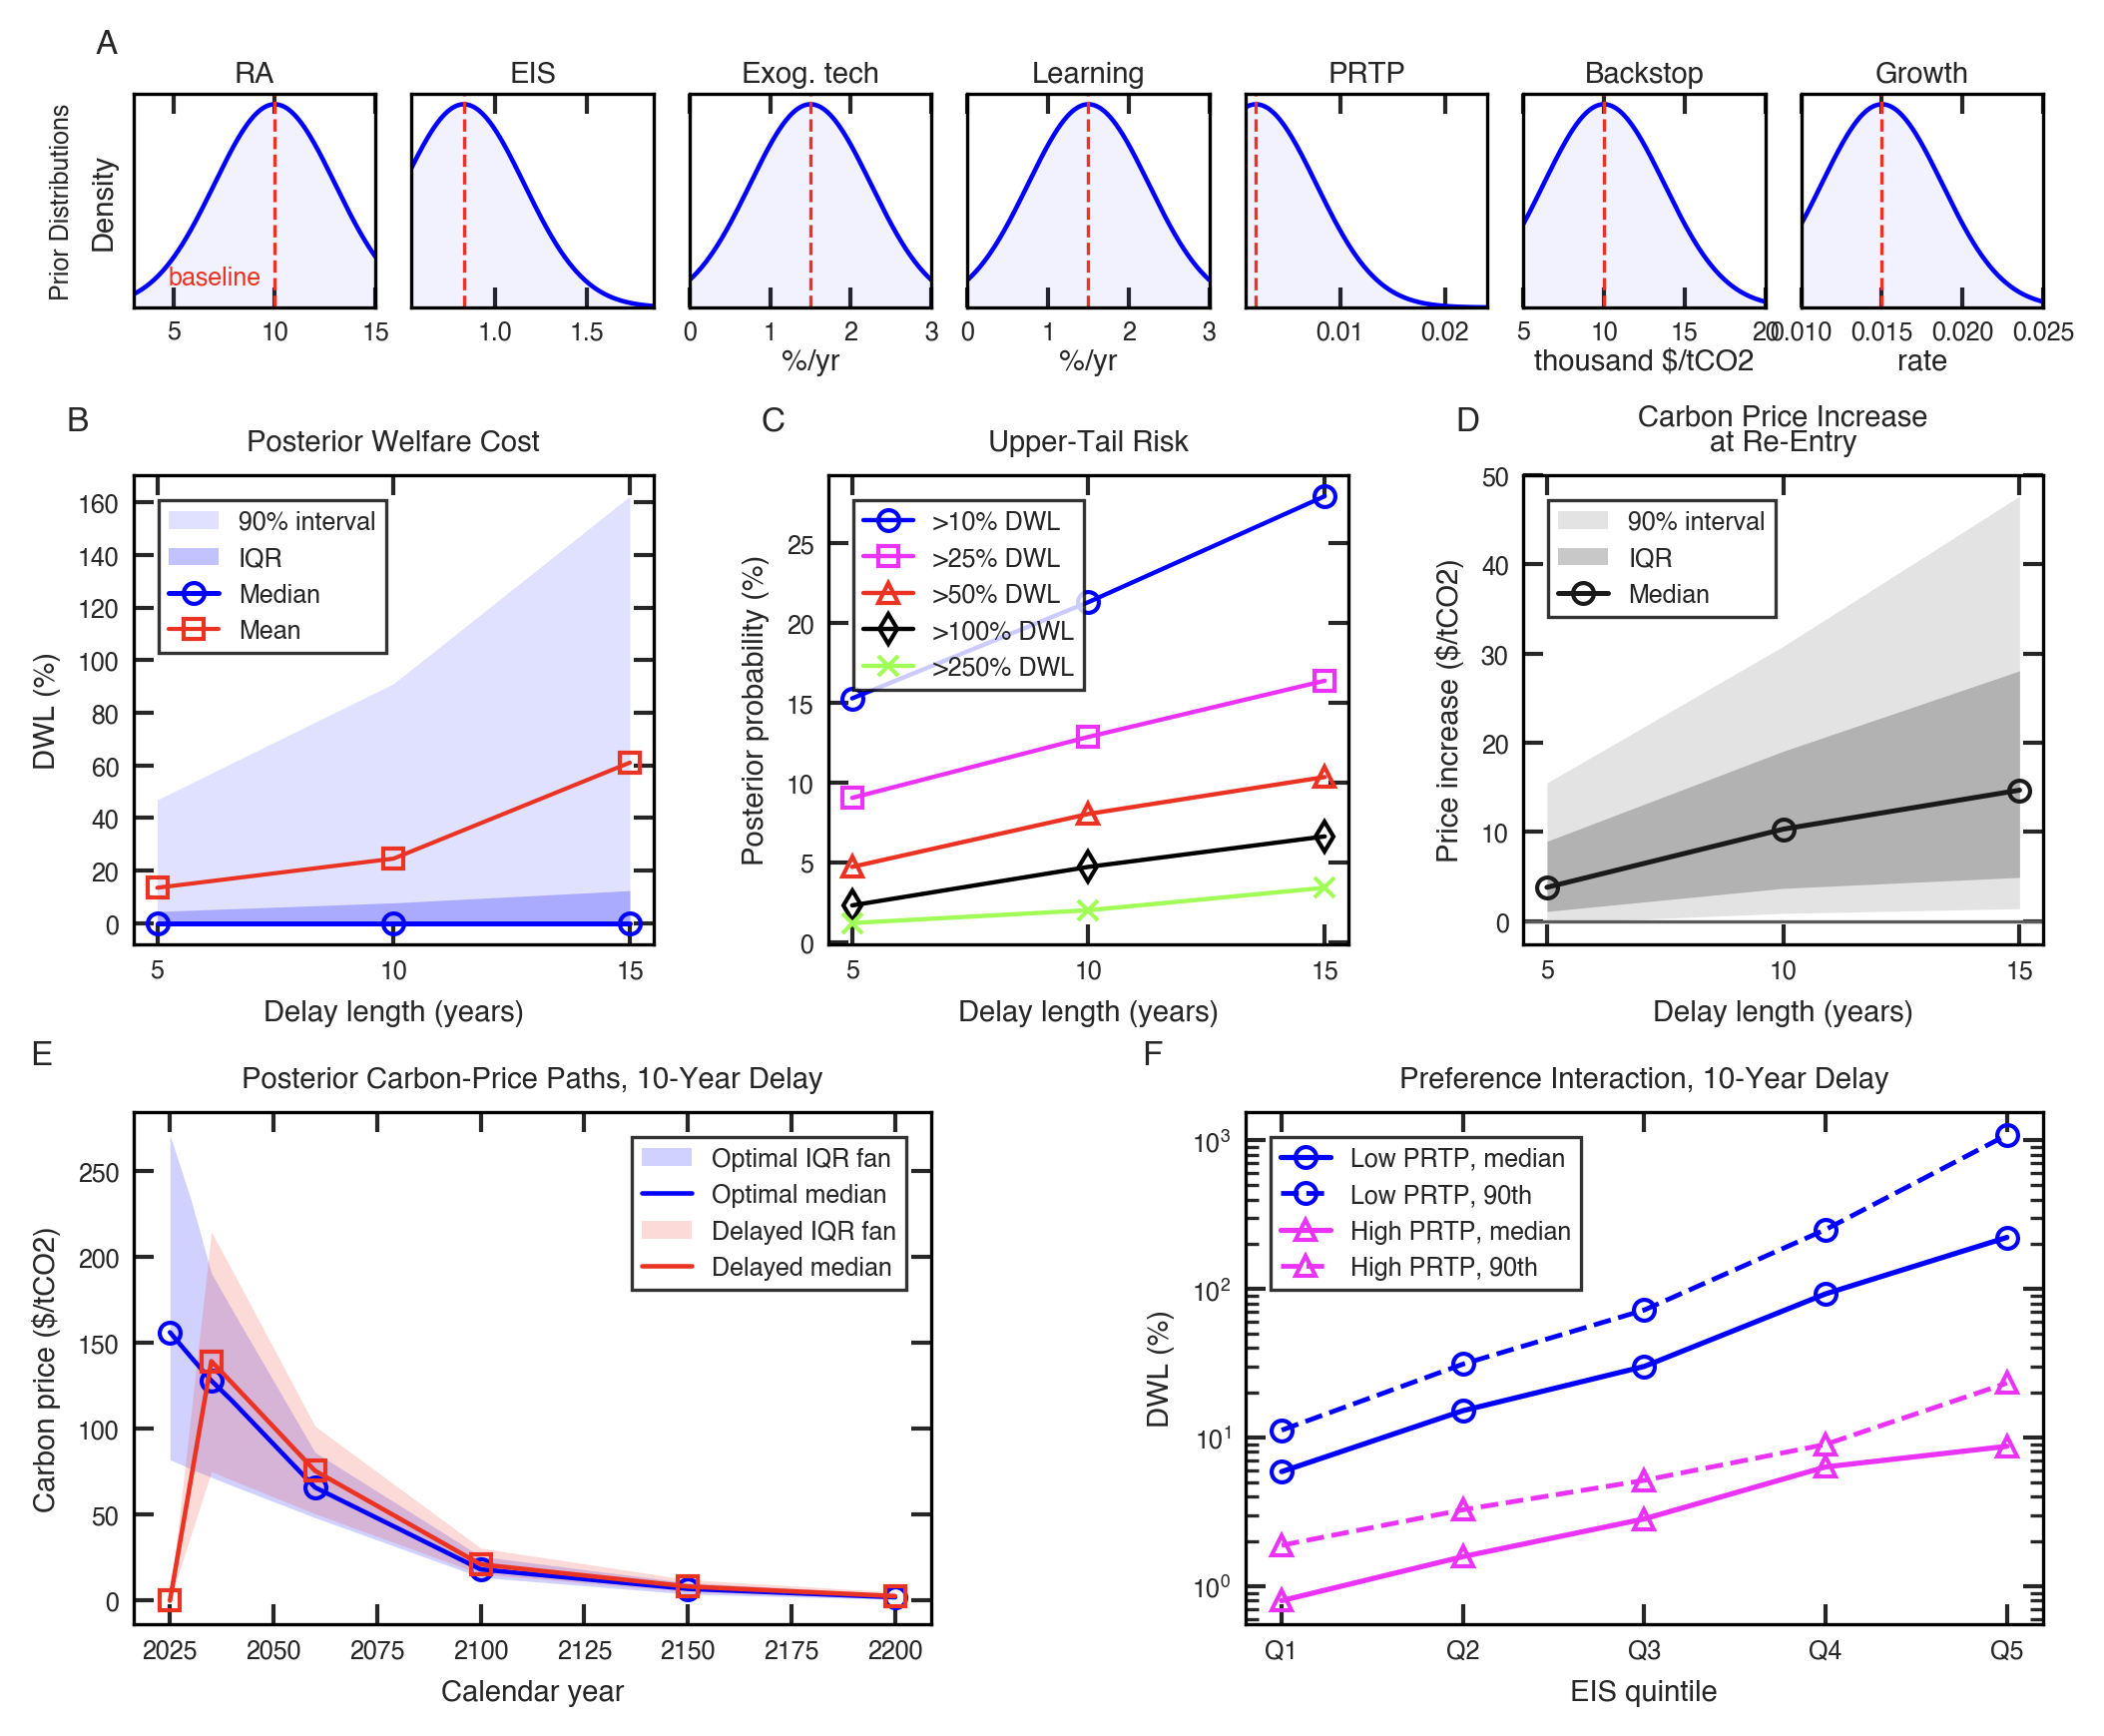

PosixPath('/Users/theomoers/Documents/Research/CKI/EZDelay/data/new_outputs/paper_facing_plots/figures/uncertainty_main_text_panel.pdf')

In [53]:
ENSEMBLE_FOLDER = "ensemble-BY2025-cons2025-samegrid-run0gauss-eisfix-v1"

from matplotlib.gridspec import GridSpec
from scipy.stats import truncnorm

ENSEMBLE_DIR = DATA_DIR / ENSEMBLE_FOLDER
if not ENSEMBLE_DIR.is_dir():
    raise FileNotFoundError(f"Required Gaussian ensemble folder not found: {ENSEMBLE_DIR}")
ENSEMBLE_ANALYSIS = ENSEMBLE_DIR / "analysis"
PARAMETER_NAMES = ["RA", "EIS", "tech_chg", "tech_scale", "PRTP", "bs_premium", "growth"]
PARAMETER_LABELS = {
    "RA": "RA",
    "EIS": "EIS",
    "tech_chg": "Exog. tech",
    "tech_scale": "Learning",
    "PRTP": "PRTP",
    "bs_premium": "Backstop",
    "growth": "Growth",
}

ensemble_results = pd.read_csv(ENSEMBLE_ANALYSIS / f"{ENSEMBLE_FOLDER}_consolidated_results.csv")
ensemble_timeseries = pd.read_csv(ENSEMBLE_ANALYSIS / f"{ENSEMBLE_FOLDER}_consolidated_timeseries.csv")
sample_files = sorted((ENSEMBLE_DIR / "samples").glob("Gaussian_samples_N*_DIMS7_BRprefs_run0mode.csv"))
if not sample_files:
    raise FileNotFoundError(f"No Gaussian sample file found under {ENSEMBLE_DIR / 'samples'}")
gaussian_samples = pd.read_csv(
    sample_files[-1],
    header=None,
    names=PARAMETER_NAMES,
)
gaussian_samples["sample_index"] = np.arange(len(gaussian_samples))

ensemble_results["sample_index"] = pd.to_numeric(ensemble_results["sample_index"], errors="coerce").astype("Int64")
ensemble_timeseries["sample_index"] = pd.to_numeric(ensemble_timeseries["sample_index"], errors="coerce").astype("Int64")
for frame in [ensemble_results, ensemble_timeseries]:
    frame["delay_year"] = pd.to_numeric(frame["delay_year"], errors="coerce")

for col in [
    "u_optimal", "u_delayed", "utility_loss", "delta_c_5yr_pct",
    "reentry_price_increase", "reentry_price_pct_increase",
    "reentry_price_annualized_increase", "deadweight_per_ton",
]:
    if col in ensemble_results.columns:
        ensemble_results[col] = pd.to_numeric(ensemble_results[col], errors="coerce")

valid_gaussian = (
    ensemble_results["sample_index"].notna()
    & ensemble_results["delay_year"].notna()
    & np.isfinite(ensemble_results["u_optimal"])
    & np.isfinite(ensemble_results["u_delayed"])
    & np.isfinite(ensemble_results["utility_loss"])
    & np.isfinite(ensemble_results["delta_c_5yr_pct"])
    & np.isfinite(ensemble_results["reentry_price_increase"])
    & ensemble_results["delta_c_5yr_pct"].ge(-1e-6)
    & ensemble_results["reentry_price_increase"].abs().le(500.0)
)
invalid_gaussian_keys = set(
    (int(row[0]), int(row[1]))
    for row in ensemble_results.loc[~valid_gaussian, ["sample_index", "delay_year"]]
    .dropna()
    .astype({"sample_index": int, "delay_year": int})
    .to_numpy(dtype=int)
)
if invalid_gaussian_keys:
    print(
        f"Excluding {len(invalid_gaussian_keys)} failed Gaussian sample-delay rows "
        f"from {ENSEMBLE_FOLDER}: {sorted(invalid_gaussian_keys)}"
    )

ensemble_results_valid = ensemble_results.loc[valid_gaussian].copy()
valid_timeseries = ~ensemble_timeseries[["sample_index", "delay_year"]].apply(
    lambda row: (int(row["sample_index"]), int(row["delay_year"])) in invalid_gaussian_keys
    if pd.notna(row["sample_index"]) and pd.notna(row["delay_year"]) else False,
    axis=1,
)
ensemble_timeseries_valid = ensemble_timeseries.loc[valid_timeseries].copy()

gaussian_plot = ensemble_results_valid.merge(gaussian_samples, on="sample_index", how="left", suffixes=("", "_sample"))
for col in ["tech_chg", "tech_scale", "bs_premium", "growth"]:
    sample_col = f"{col}_sample"
    if sample_col in gaussian_plot.columns:
        gaussian_plot[col] = gaussian_plot[sample_col]
gaussian_plot["dwl_pct"] = pd.to_numeric(gaussian_plot["delta_c_5yr_pct"], errors="coerce").clip(lower=0)
gaussian_plot["reentry_price_increase"] = pd.to_numeric(gaussian_plot["reentry_price_increase"], errors="coerce")


def qsummary(frame, value_col):
    q = frame.groupby("delay_year")[value_col].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).unstack()
    q.columns = ["p05", "p25", "median", "p75", "p95"]
    q["mean"] = frame.groupby("delay_year")[value_col].mean()
    q["n"] = frame.groupby("delay_year")[value_col].count()
    return q.reset_index()


def add_band(ax, summary, color, label="Median"):
    x = summary["delay_year"].to_numpy(dtype=float)
    ax.fill_between(x, summary["p05"], summary["p95"], color=color, alpha=0.12, linewidth=0, label="90% interval")
    ax.fill_between(x, summary["p25"], summary["p75"], color=color, alpha=0.24, linewidth=0, label="IQR")
    ax.plot(x, summary["median"], color=color, marker="o", markerfacecolor="none", linewidth=1.2, label=label)


def price_path_summary(timeseries, delay=15):
    sub = timeseries.loc[timeseries["delay_year"] == delay].copy()
    price_cols = [c for c in sub.columns if c.startswith("price_opt_") or c.startswith("price_delay_")]
    long = sub.melt(id_vars=["sample_index", "delay_year"], value_vars=price_cols, var_name="series_year", value_name="price")
    long["scenario"] = np.where(long["series_year"].str.startswith("price_opt_"), "Optimal", "Delayed")
    long["year"] = long["series_year"].str.extract(r"(\d+)$").astype(int)
    long["price"] = pd.to_numeric(long["price"], errors="coerce")
    long = long.dropna(subset=["price"])
    q = long.groupby(["scenario", "year"])["price"].quantile([0.25, 0.5, 0.75]).unstack()
    q.columns = ["p25", "median", "p75"]
    return q.reset_index()


def plot_input_distribution(ax, parameter, prior):
    values = gaussian_samples[parameter].dropna().to_numpy(dtype=float)
    run0_value = prior.mean
    x = np.linspace(prior.lower, prior.upper, 300)
    a = (prior.lower - prior.mean) / prior.std
    b = (prior.upper - prior.mean) / prior.std
    density = truncnorm.pdf(x, a, b, loc=prior.mean, scale=prior.std)
    ax.plot(x, density, color=MATLAB_COLORS[0], linewidth=1.1)
    ax.fill_between(x, 0, density, color=MATLAB_COLORS[0], alpha=0.05, linewidth=0)
    ax.axvline(run0_value, color=MATLAB_COLORS[2], linewidth=0.8, label="baseline", linestyle="--")
    if parameter == "RA":
        ax.text(run0_value - 3, ax.get_ylim()[1] * 0.2, "baseline", color=MATLAB_COLORS[2], fontsize=6.0, ha="center", va="top")
        #ax.legend(loc="lower left", frameon=True, fontsize=JOURNAL_PARAMS_fonts["legend.fontsize"], borderaxespad=1.0)
    ax.set_title(PARAMETER_LABELS[parameter], fontsize=JOURNAL_PARAMS_fonts["title.fontsize"], pad=3)
    ax.set_yticks([])
    ax.set_ylim(0, None)
    ax.set_xlim(prior.lower, prior.upper)
    ax.tick_params(axis="x", labelsize=JOURNAL_PARAMS_fonts["xtick.labelsize"], pad=3)
    if parameter in {"tech_chg", "tech_scale"}:
        ax.set_xlabel("%/yr", fontsize=JOURNAL_PARAMS_fonts["xlabel"], labelpad=1)
    elif parameter in {"growth"}:
        ax.set_xlabel("rate", fontsize=JOURNAL_PARAMS_fonts["xlabel"], labelpad=1)
    elif parameter == "bs_premium":
        ticks = np.array([5000.0, 10000.0, 15000.0, 20000.0])
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"{tick/1000:.0f}" for tick in ticks])
        ax.set_xlabel("thousand $/tCO2", fontsize=JOURNAL_PARAMS_fonts["xlabel"], labelpad=1)
    return {
        "parameter": parameter,
        "baseline": run0_value,
        "prior_lower": prior.lower,
        "prior_upper": prior.upper,
        "prior_std": prior.std,
        "sample_mean": values.mean(),
        "sample_mean_minus_baseline": values.mean() - run0_value,
        "sample_std": values.std(ddof=1),
        "sample_min": values.min(),
        "sample_max": values.max(),
        "n": len(values),
    }


def style_all_axes(fig):
    for ax in fig.axes:
        style_axes(ax)

delay_values = [5, 10, 15]
dwl_summary = qsummary(gaussian_plot.dropna(subset=["dwl_pct"]), "dwl_pct")
price_summary = qsummary(gaussian_plot.dropna(subset=["reentry_price_increase"]), "reentry_price_increase")
tail_rows = []
for delay, sub in gaussian_plot.dropna(subset=["dwl_pct"]).groupby("delay_year"):
    row = {"delay_year": delay}
    for threshold in [10, 25, 50, 100, 250]:
        row[f"gt_{threshold}"] = 100.0 * (sub["dwl_pct"] > threshold).mean()
    tail_rows.append(row)
tail = pd.DataFrame(tail_rows).sort_values("delay_year")
path_summary = price_path_summary(ensemble_timeseries_valid, delay=10)

fig = plt.figure(figsize=JOURNAL_TWO_COLUMN_TALL_FIGSIZE)
gs = fig.add_gridspec(3, 14, height_ratios=[0.5, 1.1, 1.2], hspace=0.42, wspace=0.35)

parameter_rows = []
prior_by_name = {
    "RA": dict(lower=3.0, upper=15.0, mean=10.0),
    "EIS": dict(lower=0.55, upper=1.86, mean=0.833),
    "tech_chg": dict(lower=0.0, upper=3.0, mean=1.5),
    "tech_scale": dict(lower=0.0, upper=3.0, mean=1.5),
    "PRTP": dict(lower=0.001, upper=0.024, mean=0.002),
    "bs_premium": dict(lower=5000.0, upper=20000.0, mean=10000.0),
    "growth": dict(lower=0.010, upper=0.025, mean=0.015),
}
prior_by_name = {
    name: type("Prior", (), {**values, "std": (values["upper"] - values["lower"]) / 4.0})()
    for name, values in prior_by_name.items()
}
for i, parameter in enumerate(PARAMETER_NAMES):
    ax = fig.add_subplot(gs[0, 2 * i: 2 * i + 2])
    parameter_rows.append(plot_input_distribution(ax, parameter, prior_by_name[parameter]))
    if i == 0:
        add_panel_label(ax, "A", x=-0.16, y=1.16)
        ax.set_ylabel("Density", fontsize=JOURNAL_PARAMS_fonts["ylabel"])

ax = fig.add_subplot(gs[1, 0:4])
add_panel_label(ax, "B")
add_band(ax, dwl_summary, MATLAB_COLORS[0], label="Median")
ax.plot(dwl_summary["delay_year"], dwl_summary["mean"], color=MATLAB_COLORS[2], marker="s", markerfacecolor="none", linewidth=1.0, label="Mean")
ax.set_title("Posterior Welfare Cost", fontsize=JOURNAL_PARAMS_fonts["title.fontsize"])
ax.set_xlabel("Delay length (years)", fontsize=JOURNAL_PARAMS_fonts["xlabel"])
ax.set_ylabel("DWL (%)", fontsize=JOURNAL_PARAMS_fonts["ylabel"])
ax.set_xticks(delay_values)
ax.legend(frameon=True, loc="upper left", fontsize=JOURNAL_PARAMS_fonts["legend.fontsize"], borderaxespad=1.0)

ax = fig.add_subplot(gs[1, 5:9])
add_panel_label(ax, "C")
for threshold, color, marker in [(10, MATLAB_COLORS[0], "o"), (25, MATLAB_COLORS[1], "s"), (50, MATLAB_COLORS[2], "^"), (100, MATLAB_COLORS[3], "d"), (250, MATLAB_COLORS[4], "x")]:
    ax.plot(tail["delay_year"], tail[f"gt_{threshold}"], color=color, marker=marker, markerfacecolor="none", linewidth=1.05, label=f">{threshold}% DWL")
ax.set_title("Upper-Tail Risk", fontsize=JOURNAL_PARAMS_fonts["title.fontsize"])
ax.set_xlabel("Delay length (years)", fontsize=JOURNAL_PARAMS_fonts["xlabel"])
ax.set_ylabel("Posterior probability (%)", fontsize=JOURNAL_PARAMS_fonts["ylabel"])
ax.set_xticks(delay_values)
ax.legend(frameon=True, loc="upper left", fontsize=JOURNAL_PARAMS_fonts["legend.fontsize"], borderaxespad=1.0)

ax = fig.add_subplot(gs[1, 10:14])
add_panel_label(ax, "D")
add_band(ax, price_summary, "0.1", label="Median")
ax.axhline(0, color="0.35", linewidth=0.8)
ax.set_title("Carbon Price Increase\nat Re-Entry", fontsize=JOURNAL_PARAMS_fonts["title.fontsize"], linespacing=0.9)
ax.set_xlabel("Delay length (years)", fontsize=JOURNAL_PARAMS_fonts["xlabel"])
ax.set_ylabel("Price increase ($/tCO2)", fontsize=JOURNAL_PARAMS_fonts["ylabel"])
ax.set_xticks(delay_values)
ax.legend(frameon=True, loc="upper left", fontsize=JOURNAL_PARAMS_fonts["legend.fontsize"], borderaxespad=1.0)

ax = fig.add_subplot(gs[2, 0:6])
add_panel_label(ax, "E")
real_path_years = np.array([2025, 2035, 2060, 2100, 2150, 2200], dtype=float)
for scenario, color, marker in [("Optimal", MATLAB_COLORS[0], "o"), ("Delayed", MATLAB_COLORS[2], "s")]:
    sub = path_summary.loc[path_summary["scenario"] == scenario].copy()
    x = sub["year"].to_numpy(dtype=float)
    ax.fill_between(x, sub["p25"], sub["p75"], color=color, alpha=0.18, linewidth=0, label=f"{scenario} IQR fan")
    ax.plot(x, sub["median"], color=color, linewidth=1.1, label=f"{scenario} median")
    marked = sub.loc[sub["year"].isin(real_path_years)]
    ax.plot(marked["year"], marked["median"], linestyle="none", color=color, marker=marker, markerfacecolor="none")
ax.set_title("Posterior Carbon-Price Paths, 10-Year Delay", fontsize=JOURNAL_PARAMS_fonts["title.fontsize"])
ax.set_xlabel("Calendar year", fontsize=JOURNAL_PARAMS_fonts["xlabel"])
ax.set_ylabel("Carbon price ($/tCO2)", fontsize=JOURNAL_PARAMS_fonts["ylabel"])
ax.legend(frameon=True, loc="upper right", fontsize=JOURNAL_PARAMS_fonts["legend.fontsize"], borderaxespad=1.0)

ax = fig.add_subplot(gs[2, 8:14])
add_panel_label(ax, "F")
sub = gaussian_plot.loc[gaussian_plot["delay_year"] == 10].dropna(subset=["EIS", "PRTP", "dwl_pct"]).copy()
sub = sub.loc[sub["dwl_pct"] > 0].copy()
sub["EIS_bin"] = pd.qcut(sub["EIS"], 5, labels=False, duplicates="drop") + 1
sub["PRTP_bin"] = pd.qcut(sub["PRTP"], 3, labels=False, duplicates="drop") + 1
prtp_rows = []
for (prtp_bin, eis_bin), group in sub.groupby(["PRTP_bin", "EIS_bin"], observed=True):
    if int(prtp_bin) not in (1, 3):
        continue
    prtp_rows.append({
        "prtp_bin": int(prtp_bin),
        "prtp_label": "Low PRTP" if int(prtp_bin) == 1 else "High PRTP",
        "eis_bin": int(eis_bin),
        "median_dwl_pct": group["dwl_pct"].quantile(0.50),
        "p90_dwl_pct": group["dwl_pct"].quantile(0.90),
        "n": len(group),
    })
prtp_line = pd.DataFrame(prtp_rows).sort_values(["prtp_bin", "eis_bin"])
prtp_line.to_csv(TABLE_DIR / "uncertainty_main_panel_eis_prtp_lines.csv", index=False)
for prtp_bin, color, marker in [(1, MATLAB_COLORS[0], "o"), (3, MATLAB_COLORS[1], "^")]:
    line = prtp_line.loc[prtp_line["prtp_bin"] == prtp_bin]
    label_prefix = line["prtp_label"].iloc[0]
    ax.plot(line["eis_bin"], line["median_dwl_pct"], color=color, linestyle="-", marker=marker, markerfacecolor="none", linewidth=1.25, label=f"{label_prefix}, median")
    ax.plot(line["eis_bin"], line["p90_dwl_pct"], color=color, linestyle="--", marker=marker, markerfacecolor="none", linewidth=1.15, label=f"{label_prefix}, 90th")
ax.set_title("Preference Interaction, 10-Year Delay", fontsize=JOURNAL_PARAMS_fonts["title.fontsize"])
ax.set_xlabel("EIS quintile", fontsize=JOURNAL_PARAMS_fonts["xlabel"])
ax.set_ylabel("DWL (%)", fontsize=JOURNAL_PARAMS_fonts["ylabel"])
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f"Q{i}" for i in range(1, 6)])
ax.set_yscale("log")
ax.legend(frameon=True, loc="upper left", fontsize=JOURNAL_PARAMS_fonts["legend.fontsize"], borderaxespad=1.0)
ax.text(-0.3, 0.5, "Prior Distributions", transform=fig.axes[0].transAxes, ha="center", va="center", fontsize=JOURNAL_PARAMS_fonts["annotation.fontsize"], fontweight="bold", rotation=90)

style_all_axes(fig)
fig.subplots_adjust(left=0.07, right=0.98, top=0.94, bottom=0.075)
main_uncertainty_panel_path = finish_figure(
    fig,
    "uncertainty_main_text_panel.pdf",
    figsize=JOURNAL_TWO_COLUMN_TALL_FIGSIZE,
    tight=False,
)
plt.close(fig)
main_uncertainty_panel_path